<a href="https://colab.research.google.com/github/Rellendula26/CIS5450/blob/main/cis5450finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Loan Default Risk: Lending Club Analysis

---

## 1. Introduction & Background

**Lending Club** was a peer-to-peer lending platform that connected individual investors with borrowers. This dataset contains a comprehensive record of loans issued between 2007 and 2018, including each borrower's credit profile, loan terms, and final repayment outcome.

## 2. Business & Societal Value

Accurate default prediction is critical for financial institutions. For lenders, it minimizes principal loss. For borrowers and society, well-calibrated risk models ensure credit is extended fairly — enabling financial inclusion while protecting against predatory lending to high-risk individuals.

## 3. Project Objective

Our goal is to build a binary classifier that identifies loans at risk of default at the loan-origination / investor-evaluation stage. The target variable is **`default`**:
- **0 — Fully Paid:** the borrower repaid the loan in full.
- **1 — Charged Off:** the borrower defaulted and the outstanding balance was written off.

Because `grade` and `int_rate` are assigned before final loan outcome, they are valid origination-stage predictors; however, they also mean the model partly builds on Lending Club's own underwriting/pricing signal.

## 4. Dataset Overview

The raw dataset contains ~2.26 million rows and 145 columns. After filtering to loans with a definitive outcome (Fully Paid or Charged Off), the working dataset covers loans issued between 2007 and 2018. Key variable groups include:
- **Borrower profile:** `annual_inc`, `dti`, `emp_length`, `emp_title`, `home_ownership`
- **Loan terms:** `loan_amnt`, `int_rate`, `installment`, `term`, `grade`, `purpose`
- **Credit history:** `delinq_2yrs`, `open_acc`, `revol_bal`, `revol_util`
- **Target:** `default` (0 = Fully Paid, 1 = Charged Off)

## 5. Executive Summary

This project uses EDA to identify default-related borrower and loan patterns, engineers features motivated by those findings, and compares interpretable linear models against tree-based ensembles. The final model, tuned XGBoost, provides the strongest AUC-ROC, while feature importance, hypothesis testing, and threshold analysis translate model outputs into practical lending insights.

## 6. Project Roadmap

| Step | Description |
| :--- | :---------- |
| Data Cleaning & Wrangling | Handle initial missingness, define target, parse string columns, and drop leaky post-outcome variables |
| EDA | Visualize class imbalance, distributions, raw outliers, correlations, grade risk, and affordability patterns |
| Feature Engineering | Create EDA-motivated row-level features and clean `emp_title`; defer fitted encodings until after the split |
| Preprocessing | Stratified split → train-only frequency encoding → imputation → winsorization → one-hot encoding → K-Means → scaling → SMOTE |
| Modeling | Baseline LR → ElasticNet → Decision Tree → Random Forest → XGBoost (default) → XGBoost (tuned) |
| Model Assessment | Compare AUC-ROC, precision, recall, F1, ROC curves, feature importance, and selected-feature performance |
| Hypothesis Testing | Permutation tests + bootstrap CIs for DTI, interest rate, and revolving utilization |
| Financial Analysis | Post-hoc cost-benefit analysis and decision-threshold simulation |


In [ ]:
# install kaggle api to enable dataset downloads
!pip install kaggle -q

We install the Kaggle API to pull the raw dataset directly into the runtime environment.

**Reproducibility note:** This notebook was executed in an environment with Kaggle API credentials configured. If rerunning elsewhere, either configure Kaggle credentials or manually place `loan.csv` in `/content/data/loan.csv`.


In [ ]:
import os
import subprocess

data_dir = '/content/data'
data_path = os.path.join(data_dir, 'loan.csv')
os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(data_path):
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'adarshsng/lending-club-loan-data-csv',
         '-p', data_dir, '--unzip'],
        check=True
    )
else:
    print(f'Found existing dataset at {data_path}; skipping Kaggle download.')


Found existing dataset at /content/data/loan.csv; skipping Kaggle download.


The dataset is ~340 MB. After unzipping, `loan.csv` contains over one million loan records spanning 2007–2018.

---
## Library Imports

All dependencies are imported in one place so the notebook is easy to audit and avoids scattered inline imports.


In [ ]:
!pip install pandasql imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import os
from pandasql import sqldf
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
    silhouette_score
)
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print('All libraries imported successfully.')


All libraries imported successfully.


---
## Initial Data Cleaning and Target Definition

Before EDA, we only perform cleaning needed to make the dataset usable: filtering to loans with a definitive outcome, encoding the binary target, parsing numeric fields, removing high-missingness columns, and dropping post-outcome leakage variables. Full preprocessing is deferred until after EDA and the train-test split to avoid data leakage.


In [ ]:
df = pd.read_csv('/content/data/loan.csv')
df.head(5)


/tmp/ipykernel_7764/514247114.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/data/loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# keep only completed loans — exclude 'current', 'late', and other ambiguous statuses
df = df[(df['loan_status'] == 'Fully Paid') | (df['loan_status'] == 'Charged Off')].copy()

# encode target: 0 = fully paid, 1 = charged off (default)
df['default'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)
df.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
100,NaN,NaN,30000,30000,30000.0,36 months,22.35,1151.16,D,D5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
152,NaN,NaN,40000,40000,40000.0,60 months,16.14,975.71,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
170,NaN,NaN,20000,20000,20000.0,36 months,7.56,622.68,A,A3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
186,NaN,NaN,4500,4500,4500.0,36 months,11.31,147.99,B,B3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
215,NaN,NaN,8425,8425,8425.0,36 months,27.27,345.18,E,E5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


We restrict the dataset to loans with a definitive outcome. 'Current' or 'Late' loans are excluded because their eventual result is unknown, which would introduce label noise. The resulting class distribution is roughly 80 % paid vs. 20 % defaulted.

In [ ]:
# drop any column that is more than 50% missing — these carry too little signal to be useful
missing_frac = df.isnull().mean()
cols_to_drop = missing_frac[missing_frac > 0.5].index.tolist()
df = df.drop(cols_to_drop, axis=1)
print(f'dropped {len(cols_to_drop)} columns with >50% missing values.')
df.head(5)


dropped 58 columns with >50% missing values.


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
100,30000,30000,30000.0,36 months,22.35,1151.16,D,D5,Supervisor,5 years,...,1.0,0.0,527120.0,98453.0,28600.0,101984.0,N,Cash,N,0
152,40000,40000,40000.0,60 months,16.14,975.71,C,C4,Assistant to the Treasurer (Payroll),< 1 year,...,0.0,0.0,344802.0,161720.0,45700.0,167965.0,N,Cash,N,0
170,20000,20000,20000.0,36 months,7.56,622.68,A,A3,Teacher,10+ years,...,0.0,0.0,622183.0,71569.0,85100.0,74833.0,N,Cash,N,0
186,4500,4500,4500.0,36 months,11.31,147.99,B,B3,Accounts Examiner III,10+ years,...,0.0,0.0,53795.0,29137.0,15100.0,24595.0,N,Cash,N,0
215,8425,8425,8425.0,36 months,27.27,345.18,E,E5,Senior Director Risk Management,3 years,...,0.0,0.0,768304.0,189194.0,45800.0,189054.0,N,Cash,N,0


Columns that are mostly empty (>50% null) would contribute noise rather than signal. Dropping them upfront also reduces memory usage significantly.

In [ ]:
# null handling is intentionally deferred until after the train-test split
# to avoid using test-set statistics (mean/median/mode) during imputation.
# imputation happens in the preprocessing block below, fitted on X_train only.
# here we simply verify how many nulls remain after dropping >50% missing columns.
remaining_nulls = df.isnull().sum()
remaining_nulls_nonzero = remaining_nulls[remaining_nulls > 0]
print(f'columns with remaining nulls: {len(remaining_nulls_nonzero)}')
print(remaining_nulls_nonzero.sort_values(ascending=False).head(20))


columns with remaining nulls: 47
mths_since_recent_inq         169549
num_tl_120dpd_2m              115570
mo_sin_old_il_acct            104295
emp_title                      82579
emp_length                     75454
pct_tl_nvr_dlq                 67681
avg_cur_bal                    67548
num_rev_accts                  67528
mo_sin_old_rev_tl_op           67528
mo_sin_rcnt_rev_tl_op          67528
num_actv_rev_tl                67527
total_rev_hi_lim               67527
tot_cur_bal                    67527
tot_coll_amt                   67527
num_il_tl                      67527
total_il_high_credit_limit     67527
tot_hi_cred_lim                67527
num_tl_op_past_12m             67527
num_op_rev_tl                  67527
num_rev_tl_bal_gt_0            67527
dtype: int64


Columns with more than 50% missing values have already been dropped. Remaining nulls are sparse — imputation statistics (median for numerics, mode for categoricals) will be computed on the training partition only, after the train-test split, to prevent test-set information from influencing the imputation values.


In [ ]:
# winsorization (clipping at 1st/99th percentile) is also deferred until after
# the train-test split. percentile bounds will be computed on X_train only,
# then applied to both X_train and X_test, preventing test-set leakage.
# here we preview the raw distribution shape to motivate the clipping decision.
skew_preview = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
print('Top 10 most right-skewed numeric columns (motivates winsorization):')
print(skew_preview.head(10))


Top 10 most right-skewed numeric columns (motivates winsorization):
tot_coll_amt          656.493966
delinq_amnt            94.116733
total_rev_hi_lim       53.291364
annual_inc             47.115445
num_tl_120dpd_2m       45.321078
tax_liens              33.307203
dti                    26.268444
acc_now_delinq         21.779773
num_tl_30dpd           20.914332
total_rec_late_fee     18.954768
dtype: float64


Several features — particularly `annual_inc` and `revol_bal` — are heavily right-skewed, confirming that winsorization is warranted. Clipping bounds (1st/99th percentiles) will be computed strictly on the training set in the preprocessing block below and then applied to both partitions, so no test-set information influences the bounds.


In [ ]:
# inspect remaining missing values after initial cleaning
# these are intentionally NOT imputed here; imputation is fitted on X_train only later
total_missing = df.isnull().sum()
total_missing[total_missing > 0].sort_values(ascending=False).head(20)


,0
mths_since_recent_inq,169549
num_tl_120dpd_2m,115570
mo_sin_old_il_acct,104295
emp_title,82579
emp_length,75454
pct_tl_nvr_dlq,67681
avg_cur_bal,67548
num_rev_accts,67528
mo_sin_old_rev_tl_op,67528
mo_sin_rcnt_rev_tl_op,67528


In [ ]:
# parse string-encoded columns into usable numeric types using regex
# 'term' is stored as '36 months' — extract the integer
df['term'] = df['term'].apply(lambda x: int(x.split()[0]))

# 'emp_length' is stored as '5 years' or '10+ years' — extract leading digit(s), fill missing with 0
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float).fillna(0)

display(df.head(5))


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
100,30000,30000,30000.0,36,22.35,1151.16,D,D5,Supervisor,5.0,...,1.0,0.0,527120.0,98453.0,28600.0,101984.0,N,Cash,N,0
152,40000,40000,40000.0,60,16.14,975.71,C,C4,Assistant to the Treasurer (Payroll),1.0,...,0.0,0.0,344802.0,161720.0,45700.0,167965.0,N,Cash,N,0
170,20000,20000,20000.0,36,7.56,622.68,A,A3,Teacher,10.0,...,0.0,0.0,622183.0,71569.0,85100.0,74833.0,N,Cash,N,0
186,4500,4500,4500.0,36,11.31,147.99,B,B3,Accounts Examiner III,10.0,...,0.0,0.0,53795.0,29137.0,15100.0,24595.0,N,Cash,N,0
215,8425,8425,8425.0,36,27.27,345.18,E,E5,Senior Director Risk Management,3.0,...,0.0,0.0,768304.0,189194.0,45800.0,189054.0,N,Cash,N,0


In [ ]:
# drop leaky features (populated only after a default occurs) and uninformative identifiers
leaky_and_unneeded = [
    'loan_status', 'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
    'recoveries', 'collection_recovery_fee', 'total_rec_late_fee',
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_inv', 'total_rec_prncp', 'total_rec_int'
]
for col in leaky_and_unneeded:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print(f'remaining columns: {df.shape[1]}')
df.head(5)


remaining columns: 76


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
100,30000,30000,30000.0,36,22.35,1151.16,D,D5,Supervisor,5.0,...,1.0,0.0,527120.0,98453.0,28600.0,101984.0,N,Cash,N,0
152,40000,40000,40000.0,60,16.14,975.71,C,C4,Assistant to the Treasurer (Payroll),1.0,...,0.0,0.0,344802.0,161720.0,45700.0,167965.0,N,Cash,N,0
170,20000,20000,20000.0,36,7.56,622.68,A,A3,Teacher,10.0,...,0.0,0.0,622183.0,71569.0,85100.0,74833.0,N,Cash,N,0
186,4500,4500,4500.0,36,11.31,147.99,B,B3,Accounts Examiner III,10.0,...,0.0,0.0,53795.0,29137.0,15100.0,24595.0,N,Cash,N,0
215,8425,8425,8425.0,36,27.27,345.18,E,E5,Senior Director Risk Management,3.0,...,0.0,0.0,768304.0,189194.0,45800.0,189054.0,N,Cash,N,0


Features like `recoveries` and `total_pymnt` are recorded *after* a loan defaults, so including them would be a form of data leakage — the model would be 'cheating' by using information it could not have at the time of prediction. Identifier columns (id, url, zip_code) carry no predictive signal and are also removed.

In [ ]:
# select the highest-signal features for modeling
# fico_range_low is intentionally excluded — it has >50% missing values in this
# vintage of the dataset and was already dropped by the missing-data filter above
features = [
    'annual_inc', 'dti', 'delinq_2yrs', 'open_acc',
    'revol_bal', 'revol_util', 'emp_length', 'emp_title',
    'loan_amnt', 'int_rate', 'installment', 'term',
    'grade', 'home_ownership', 'purpose', 'default'
]
df_cols = [col for col in features if col in df.columns]

df_features = df[df_cols].copy()
print(f'modeling dataset shape: {df_features.shape}')
print(f'columns: {df_features.columns.tolist()}')
df_features.head()


modeling dataset shape: (1303607, 16)
columns: ['annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'revol_bal', 'revol_util', 'emp_length', 'emp_title', 'loan_amnt', 'int_rate', 'installment', 'term', 'grade', 'home_ownership', 'purpose', 'default']


,annual_inc,dti,delinq_2yrs,open_acc,revol_bal,revol_util,emp_length,emp_title,loan_amnt,int_rate,installment,term,grade,home_ownership,purpose,default
100,100000.0,30.46,0.0,11.0,15603,37.0,5.0,Supervisor,30000,22.35,1151.16,36,D,MORTGAGE,debt_consolidation,0
152,45000.0,50.53,0.0,18.0,34971,64.5,1.0,Assistant to the Treasurer (Payroll),40000,16.14,975.71,60,C,MORTGAGE,credit_card,0
170,100000.0,18.92,0.0,9.0,25416,29.9,10.0,Teacher,20000,7.56,622.68,36,A,MORTGAGE,credit_card,0
186,38500.0,4.64,0.0,12.0,4472,15.3,10.0,Accounts Examiner III,4500,11.31,147.99,36,B,RENT,credit_card,0
215,450000.0,12.37,0.0,21.0,36812,65.7,3.0,Senior Director Risk Management,8425,27.27,345.18,36,E,MORTGAGE,credit_card,0


We narrow the dataset to a compact set of domain-relevant features, keeping borrower credit history, loan terms, employment text, and categorical loan descriptors. This reduces noise from less interpretable columns and keeps the feature space manageable. Note that `fico_range_low` is unavailable in this Kaggle vintage of the dataset (>50% missing); we instead rely on the loan grade and interest rate, which are themselves credit-risk-derived signals, to capture creditworthiness.


---
## Exploratory Data Analysis (EDA)

EDA validates and contextualises our modelling decisions by surfacing distributional properties, feature–target relationships, class imbalance, raw outliers, and multicollinearity. Each plot is followed by a written interpretation that explicitly links the finding to a downstream feature-engineering, preprocessing, or modelling choice.

At this stage, `df_features` is still lightly cleaned and mostly raw. Main feature engineering comes after EDA so that the notebook story is: **EDA finding → motivated feature engineering → leakage-safe preprocessing → modelling**.

| EDA Plot | Purpose | Downstream decision informed |
| :--- | :--- | :--- |
| 1. Class distribution | Quantify imbalance | Use SMOTE / class weighting + AUC-ROC, not accuracy alone |
| 2. Feature distributions (KDE) | Identify discriminative features | Prioritise interest rate, DTI, utilization, income |
| 3. Raw outlier analysis | Identify extreme numeric values | Fit 1st/99th percentile clipping on training set only |
| 4. Correlation heatmap | Detect multicollinearity | Retain related features while using regularization/ensembles |
| 5. Default rate by grade | Validate data integrity and underwriting signal | Include grade and interest rate with proper caveats |
| 6. Affordability signal preview | Motivate `payment_to_income` | Engineer affordability feature after EDA |
| 7. Summary statistics | Quantify class separation | Confirm feature priorities for modelling |


In [ ]:
# shared color palette and label map — used consistently across all plots
palette     = {0: '#4C8BE8', 1: '#E85D4C'}
labels      = {0: 'Fully Paid', 1: 'Charged Off'}
label_names = ['Fully Paid', 'Charged Off']


### EDA 1: Class Distribution

We first examine how balanced the target variable is, since severe imbalance will require correction during training.


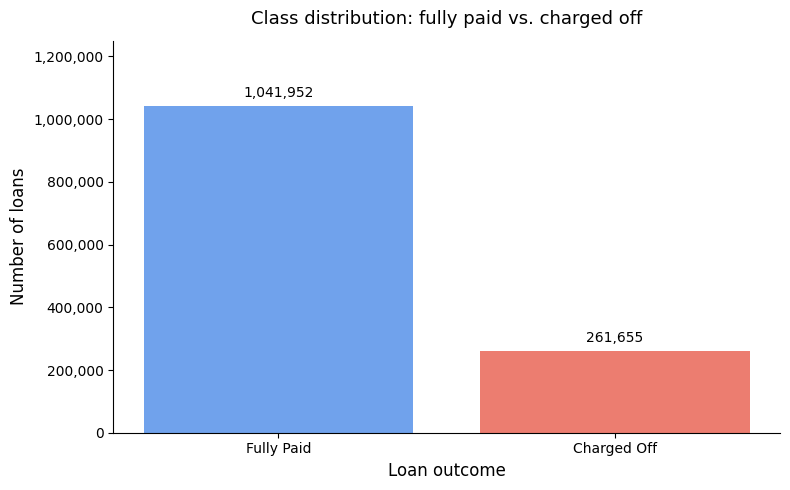

In [ ]:
# count loans in each class and plot as a bar chart
class_counts = df_features['default'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(label_names, class_counts.values,
              color=[palette[i] for i in class_counts.index], alpha=0.8)
ax.bar_label(bars, labels=[f'{x:,.0f}' for x in class_counts.values], padding=4)
ax.set_title('Class distribution: fully paid vs. charged off', fontsize=13, pad=12)
ax.set_xlabel('Loan outcome', fontsize=12)
ax.set_ylabel('Number of loans', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, class_counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()


The target is imbalanced: fully paid loans substantially outnumber charged-off loans. A naive model that predicts 'fully paid' for every loan would achieve high accuracy while failing the actual business goal. Therefore, later model evaluation focuses on AUC-ROC, precision, recall, and F1 rather than accuracy alone. The imbalance also motivates SMOTE for linear models and class-weighted / cost-sensitive approaches for tree-based models.


### EDA 2: Feature Distributions by Default Status

KDE plots show how key financial variables are distributed across the two classes. A clear separation between the distributions indicates the feature has predictive value.


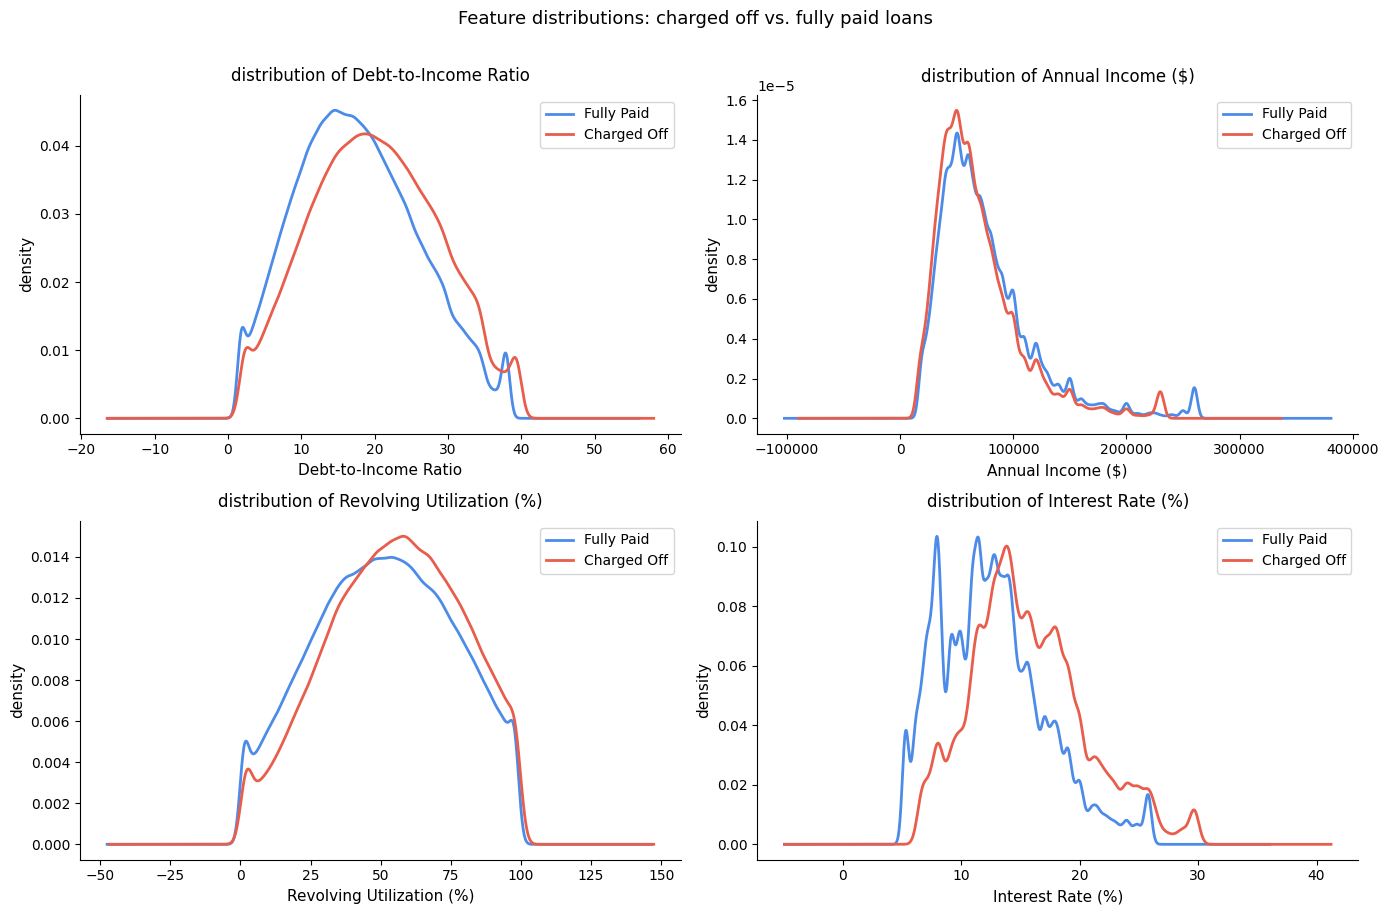

In [ ]:
features_to_plot = {
    'dti':       'Debt-to-Income Ratio',
    'annual_inc':'Annual Income ($)',
    'revol_util':'Revolving Utilization (%)',
    'int_rate':  'Interest Rate (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features_to_plot.items()):
    for label_val, group in df_features.groupby('default')[col]:
        # clip to 1st–99th percentile for visual clarity only — this affects the plot, not the data
        group_clipped = group.clip(lower=group.quantile(0.01), upper=group.quantile(0.99))
        group_clipped.plot.kde(ax=ax, label=labels[label_val],
                               color=palette[label_val], linewidth=2)
    ax.set_title(f'distribution of {title}', fontsize=12, pad=10)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('density', fontsize=11)
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

plt.suptitle('Feature distributions: charged off vs. fully paid loans', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


`int_rate` shows the sharpest separation: defaulted loans cluster at higher rates, consistent with Lending Club's risk-based pricing model. `revol_util`, `annual_inc`, and `dti` also show visible class differences. These patterns motivate keeping all four as model inputs, engineering affordability/risk-interaction features after EDA, and formally testing the DTI, interest-rate, and revolving-utilization differences in the hypothesis-testing section.


### EDA 3: Raw Outlier Analysis

We visualise the raw pre-winsorization distributions of the most skewed numeric features using boxplots. This justifies winsorising at the 1st/99th percentiles during preprocessing — but the actual clipping bounds are fitted only on the training set after the train-test split.


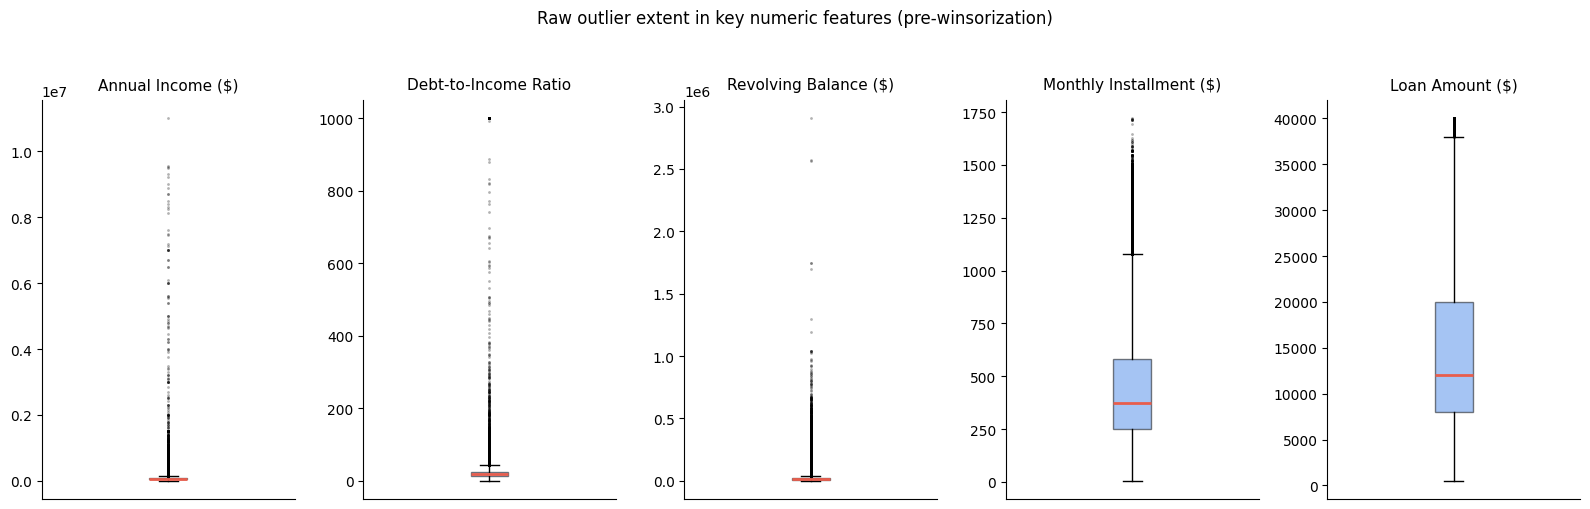

In [ ]:
# boxplots to visualise raw outlier extent before winsorization
outlier_cols = ['annual_inc', 'dti', 'revol_bal', 'installment', 'loan_amnt']
outlier_labels = [
    'Annual Income ($)', 'Debt-to-Income Ratio',
    'Revolving Balance ($)', 'Monthly Installment ($)', 'Loan Amount ($)'
]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
for ax, col, label in zip(axes, outlier_cols, outlier_labels):
    ax.boxplot(df_features[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C8BE8', alpha=0.5),
               medianprops=dict(color='#E85D4C', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3, color='gray'))
    ax.set_title(label, fontsize=11, pad=8)
    ax.set_xticks([])
    sns.despine(ax=ax)

plt.suptitle('Raw outlier extent in key numeric features (pre-winsorization)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


The boxplots show the raw pre-winsorization distributions. `annual_inc`, `dti`, and `revol_bal` have strong right tails, meaning a small number of extreme borrowers could dominate distance-based models and linear coefficients. Winsorization is therefore appropriate, but it is implemented later using training-set 1st/99th percentile bounds so that the test set does not influence the clipping thresholds.


### EDA 4: Correlation Heatmap

A correlation matrix surfaces multicollinearity — pairs of features that are highly correlated with each other. Models like Logistic Regression are sensitive to this because correlated predictors produce unstable coefficient estimates.


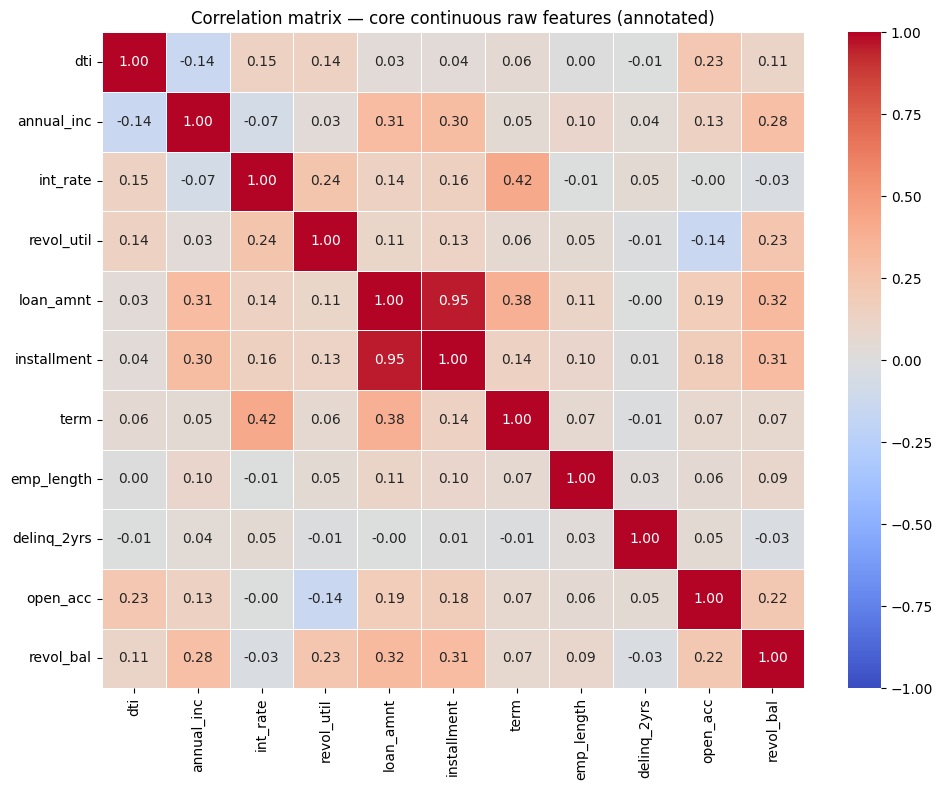

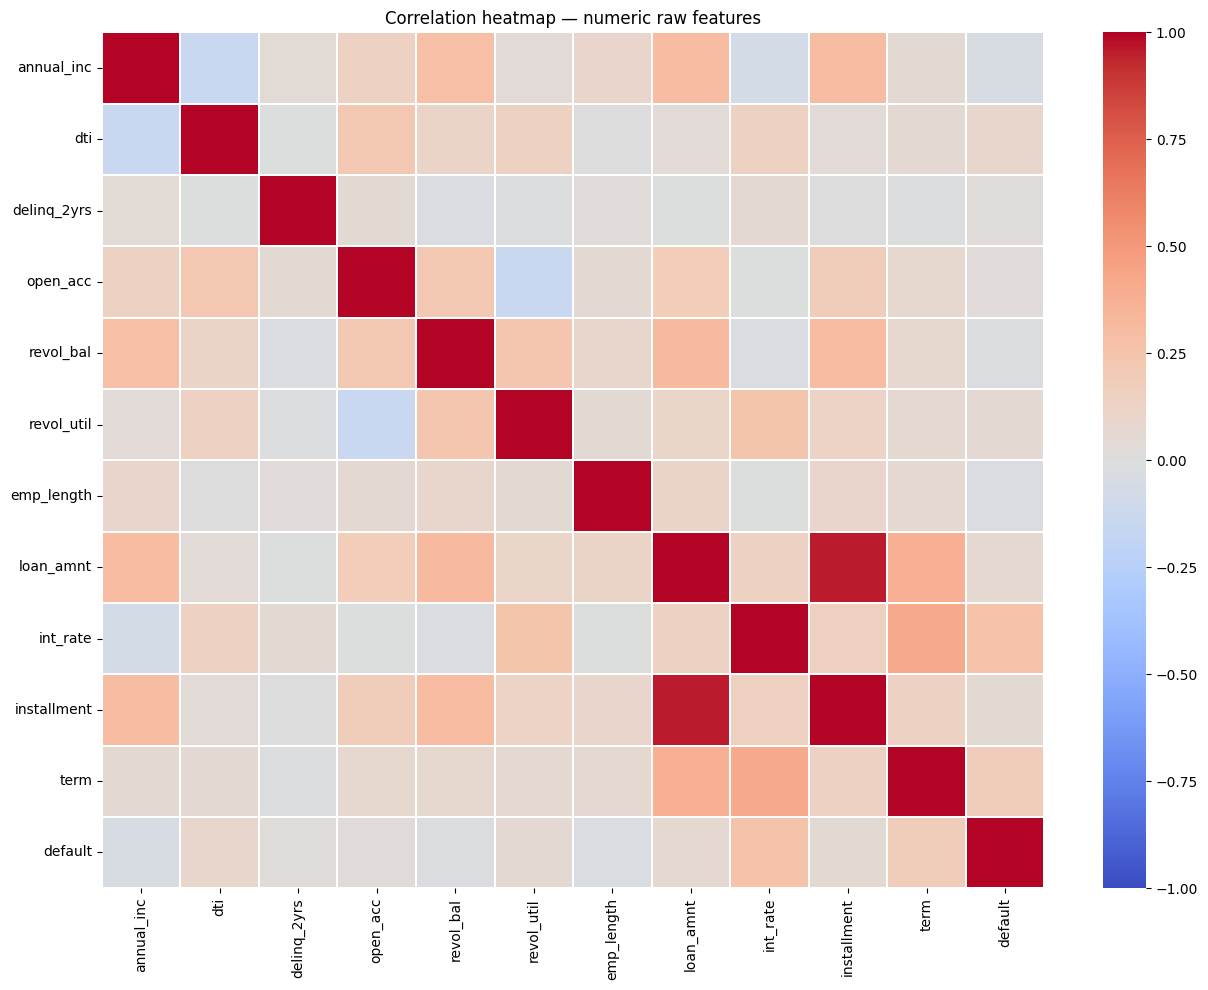

In [ ]:
# EDA 4a: annotated heatmap of core continuous raw features
# engineered features are intentionally excluded here because they are created after EDA
core_features = [
    'dti', 'annual_inc', 'int_rate', 'revol_util', 'loan_amnt',
    'installment', 'term', 'emp_length', 'delinq_2yrs', 'open_acc', 'revol_bal'
]
core_available = [f for f in core_features if f in df_features.columns]
corr_core = df_features[core_available].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_core, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white')
plt.title('Correlation matrix — core continuous raw features (annotated)', fontsize=12)
plt.tight_layout()
plt.show()

# EDA 4b: full heatmap across all currently numeric raw features
numeric_features = df_features.select_dtypes(include=[np.number])
corr = numeric_features.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.3, linecolor='white')
plt.title('Correlation heatmap — numeric raw features', fontsize=12)
plt.tight_layout()
plt.show()


The core heatmap shows three main relationships. `loan_amnt` and `installment` are highly correlated (r = 0.95) because larger loans produce larger monthly payments, but both are retained because they capture different risks: total exposure vs. monthly repayment burden.

`dti` is strongly correlated with `dti_int_interaction` (r = 0.85) because the interaction term is built from DTI. `int_rate` is also moderately correlated with this interaction feature (r = 0.55), confirming that it captures combined debt burden and borrowing cost.

Overall, the heatmaps show limited widespread multicollinearity beyond these expected engineered/loan-structure relationships. The clearest target-related signal is `int_rate`, with smaller supporting signals from `dti`, `term`, and `dti_int_interaction`.

### EDA 5: Default Rate by Loan Grade

Lending Club assigns grades A–G to loans, where A is the safest. This chart validates the dataset: if the grades are meaningful, default rates should rise monotonically from A to G.


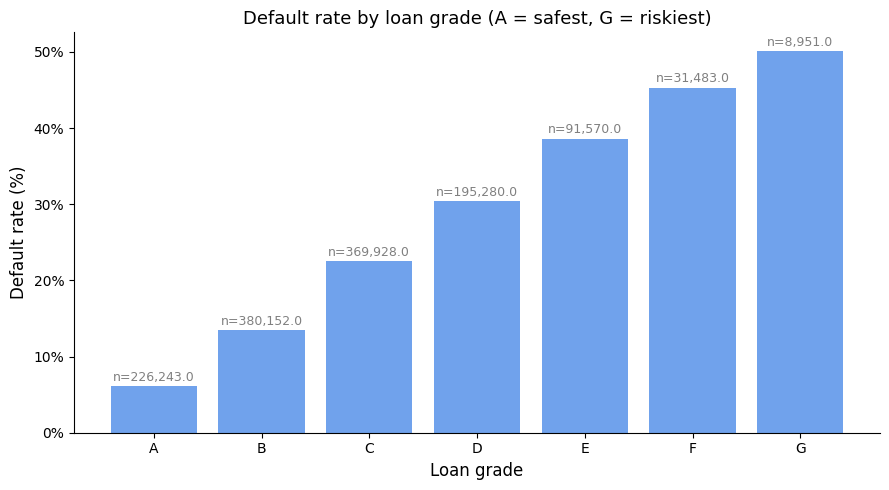

In [ ]:
# use the original loan grade directly; one-hot encoding is deferred until after the split
grade_default_rate = (
    df_features.groupby('grade')['default']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n_loans'})
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(grade_default_rate.index, grade_default_rate['default_rate'] * 100,
              color='#4C8BE8', alpha=0.8)

for bar, (grade, row) in zip(bars, grade_default_rate.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'n={row["n_loans"]:,}',
        ha='center', va='bottom', fontsize=9, color='gray'
    )

ax.set_title('Default rate by loan grade (A = safest, G = riskiest)', fontsize=13)
ax.set_xlabel('Loan grade', fontsize=12)
ax.set_ylabel('Default rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()


Default rates rise monotonically from A to G, validating that Lending Club's internal grading system carries strong risk information. Because grade and interest rate are assigned before final loan outcome, they are valid predictors for an origination-stage or investor-facing risk model. However, they also mean the model partly builds on Lending Club's existing underwriting signal, so any deployment should audit whether those assigned grades/rates encode bias.


### EDA 6: Motivation for Affordability-Based Features

The previous EDA suggests that default risk is not driven by one variable alone. Debt burden, monthly installment size, annual income, and interest rate interact. Here we preview an affordability ratio locally for EDA only; the actual persistent `payment_to_income` feature is created in the next feature-engineering section.


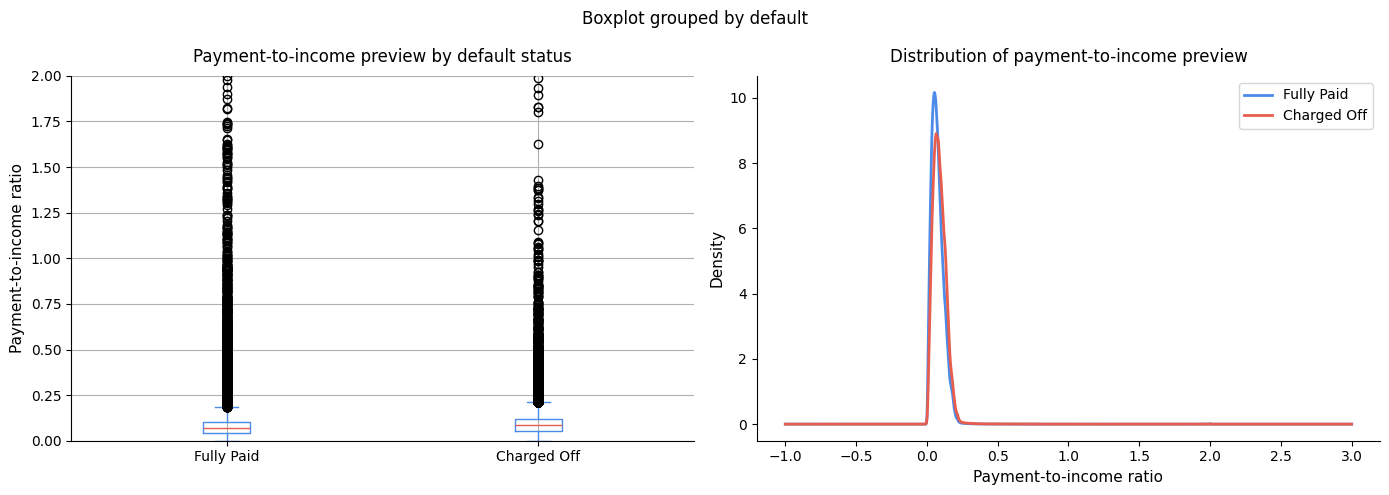

In [ ]:
# local EDA-only preview; this does not yet modify df_features
payment_to_income_preview = df_features['installment'] / (df_features['annual_inc'].replace(0, np.nan) / 12)
eda_affordability = pd.DataFrame({
    'default': df_features['default'],
    'payment_to_income_preview': payment_to_income_preview
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: boxplot — compare medians and spread between classes
eda_affordability.boxplot(
    column='payment_to_income_preview', by='default', ax=axes[0],
    boxprops=dict(color=palette[0]),
    medianprops=dict(color=palette[1]),
    whiskerprops=dict(color=palette[0]),
    capprops=dict(color=palette[0])
)
axes[0].set_title('Payment-to-income preview by default status', fontsize=12, pad=10)
axes[0].set_xlabel('')
axes[0].set_xticklabels(label_names)
axes[0].set_ylabel('Payment-to-income ratio', fontsize=11)
axes[0].set_ylim(0, 2)

# right: kde — show the full distributional difference
for label_val, group in eda_affordability.groupby('default')['payment_to_income_preview']:
    group.clip(upper=2).plot.kde(
        ax=axes[1], label=labels[label_val],
        color=palette[label_val], linewidth=2
    )
axes[1].set_title('Distribution of payment-to-income preview', fontsize=12, pad=10)
axes[1].set_xlabel('Payment-to-income ratio', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend()
sns.despine()

plt.tight_layout()
plt.show()


The distributions are very similar between classes — both concentrate tightly in the 0–0.2 range with heavily overlapping KDE curves. The difference is subtle: charged-off loans have a marginally higher median and a slightly heavier right tail beyond 0.2. While this affordability ratio is not a strong standalone separator, it captures monthly loan burden relative to income and may add value in combination with DTI and interest rate. This motivates creating `payment_to_income` as a model feature after EDA.


### EDA 7: Summary Statistics by Default Status

A tabular comparison of mean feature values across classes provides a concise, quantitative summary of the EDA findings and directly informs which features to prioritise in modelling.


In [ ]:
# summary statistics use raw features plus local EDA-only previews for motivated engineered features
summary_eda = df_features.copy()
summary_eda['payment_to_income_preview'] = (
    summary_eda['installment'] / (summary_eda['annual_inc'].replace(0, np.nan) / 12)
)
summary_eda['dti_int_interaction_preview'] = summary_eda['dti'] * summary_eda['int_rate']

key_cols = [
    'dti', 'int_rate', 'annual_inc', 'revol_util',
    'installment', 'loan_amnt',
    'payment_to_income_preview', 'dti_int_interaction_preview'
]
available_key_cols = [c for c in key_cols if c in summary_eda.columns]

summary = summary_eda.groupby('default')[available_key_cols].mean().T
summary.columns = ['Fully Paid (mean)', 'Charged Off (mean)']
summary['Difference'] = summary['Charged Off (mean)'] - summary['Fully Paid (mean)']
summary['% Difference'] = (summary['Difference'] / summary['Fully Paid (mean)'] * 100).round(1)

display(summary.style.background_gradient(subset=['% Difference'], cmap='RdYlGn_r'))


,Fully Paid (mean),Charged Off (mean),Difference,% Difference
dti,17.780909,20.161590,2.380681,13.400000
int_rate,12.640755,15.712087,3.071331,24.300000
annual_inc,77623.326376,70327.779235,-7295.547140,-9.400000
revol_util,51.160233,54.896443,3.736211,7.300000
installment,431.388962,464.749514,33.360551,7.700000
loan_amnt,14132.493699,15548.979381,1416.485682,10.000000
payment_to_income_preview,0.128832,0.114890,-0.013942,-10.800000
dti_int_interaction_preview,231.295793,323.379541,92.083748,39.800000


The table quantifies what the KDE plots suggested qualitatively. Interest rate shows the largest percentage difference between classes, consistent with it being the strongest single separator. DTI is elevated for defaulters and is later tested formally. Annual income is lower for defaulters, as expected. The preview affordability and interaction features show that borrower burden is multi-dimensional, motivating the engineered features created in the next section.


---
## Feature Engineering Motivated by EDA

EDA showed that default risk is tied to debt burden, borrowing cost, affordability, grade, and borrower-profile signals. We now create only features that are either row-level transformations or text-cleaning steps. Any transformation that must be **fitted** from data — frequency encoding, imputation, winsorization, scaling, K-Means, and SMOTE — is deferred until after the train-test split.

Features created here:
1. **`dti_int_interaction`** = DTI × interest rate, capturing compounded debt burden and borrowing cost.
2. **`payment_to_income`** = monthly installment ÷ monthly income, capturing affordability pressure.
3. **`emp_title_clean`** = regex-standardized employment title text, used later for train-only frequency encoding.
4. **PandaSQL grade profile** = a course-topic aggregation that validates the grade/default-rate relationship seen in EDA.

Because `dti_int_interaction` and `payment_to_income` are row-level transformations, they can be created before the split: each value depends only on that loan's own information, not on statistics learned from the full dataset.


In [ ]:
from IPython.display import display # Import display for use with grade_risk_profile

# 1. row-level interaction term: DTI × interest rate captures compounded financial stress
df_features['dti_int_interaction'] = df_features['dti'] * df_features['int_rate']

# 2. row-level affordability ratio: monthly installment relative to monthly income
# protect against division by zero by replacing 0 income with NaN first
annual_inc_safe = df_features['annual_inc'].replace(0, np.nan)
df_features['payment_to_income'] = df_features['installment'] / (annual_inc_safe / 12)
# do NOT fill NaN here — defer to post-split imputation

# 3. regex-clean employment title text; frequency encoding is fitted after the split
def clean_title(text):
    if pd.isna(text):
        return 'unknown'
    return re.sub(r'[^a-zA-Z\s]', '', str(text)).lower().strip()

if 'emp_title' in df_features.columns:
    df_features['emp_title_clean'] = df_features['emp_title'].apply(clean_title)
    print(f"emp_title_clean: {df_features['emp_title_clean'].nunique():,} unique cleaned titles")
    print(f"top 5 cleaned titles: {df_features['emp_title_clean'].value_counts().head(5).to_dict()}")
else:
    df_features['emp_title_clean'] = 'unknown'
    print('emp_title not available — emp_title_clean set to constant unknown')

# 4. PandaSQL: aggregate default rate and mean interest rate by loan grade
pquery = """
    SELECT grade,
           COUNT(*) AS n_loans,
           ROUND(AVG(int_rate), 2) AS avg_int_rate,
           ROUND(AVG(CAST(`default` AS FLOAT)), 3) AS default_rate
    FROM df_features
    WHERE grade IS NOT NULL
    GROUP BY grade
    ORDER BY grade
"""
grade_risk_profile = sqldf(pquery, {'df_features': df_features})
print('\nGrade-level risk profile (PandaSQL):')
display(grade_risk_profile)

print(f'\nfeature engineering complete. df_features shape: {df_features.shape}')
display(df_features.head(3))

emp_title_clean: 292,738 unique cleaned titles
top 5 cleaned titles: {'unknown': 82579, 'teacher': 25773, 'manager': 25271, 'owner': 15424, 'registered nurse': 12526}

Grade-level risk profile (PandaSQL):


,grade,n_loans,avg_int_rate,default_rate
0,A,226243,7.12,0.061
1,B,380152,10.69,0.134
2,C,369928,14.02,0.225
3,D,195280,17.70,0.304
4,E,91570,21.10,0.386
5,F,31483,24.90,0.453
6,G,8951,27.69,0.501



feature engineering complete. df_features shape: (1303607, 19)


,annual_inc,dti,delinq_2yrs,open_acc,revol_bal,revol_util,emp_length,emp_title,loan_amnt,int_rate,installment,term,grade,home_ownership,purpose,default,dti_int_interaction,payment_to_income,emp_title_clean
100,100000.0,30.46,0.0,11.0,15603,37.0,5.0,Supervisor,30000,22.35,1151.16,36,D,MORTGAGE,debt_consolidation,0,680.7810,0.138139,supervisor
152,45000.0,50.53,0.0,18.0,34971,64.5,1.0,Assistant to the Treasurer (Payroll),40000,16.14,975.71,60,C,MORTGAGE,credit_card,0,815.5542,0.260189,assistant to the treasurer payroll
170,100000.0,18.92,0.0,9.0,25416,29.9,10.0,Teacher,20000,7.56,622.68,36,A,MORTGAGE,credit_card,0,143.0352,0.074722,teacher


The engineered features are now available for modeling, but leakage-sensitive transformations are still deferred. In particular, `emp_title_freq` is **not** computed here because frequency encoding learns distributional information from the dataset; it is fitted on the training set only in the preprocessing block.


---
## Data Preprocessing: Split → Train-Only Transforms → Scale → Resample

The preprocessing pipeline runs **once**, in the following strict order, to prevent data leakage:

1. **Stratified train-test split (80/20)** — `stratify=y` preserves the ~80/20 class ratio in both splits. This happens before any fitted transformation.
2. **Train-only frequency encoding** — `emp_title_freq` is learned from `X_train` title frequencies only; unseen test titles receive 0.
3. **Imputation** — median for numerics and mode for categoricals, fitted on `X_train` only, then applied to both partitions.
4. **Winsorization** — 1st/99th percentile bounds computed on `X_train` only, then applied to both.
5. **One-hot encoding** — categorical columns are encoded after the split; train/test columns are aligned to the training feature space.
6. **K-Means borrower segmentation** — clustering scaler, k-selection, and centroids are fitted on training data only; test rows are assigned using the trained model.
7. **StandardScaler** — fit only on final `X_train`, then applied to `X_test`.
8. **SMOTE** — applied only to the scaled training set; the test set remains untouched.

Logistic Regression and ElasticNet train on the SMOTE-balanced data (`X_train_res`). Tree-based models train on the original unbalanced data (`X_train_scaled`) and handle imbalance via `class_weight` or `scale_pos_weight`.


In [ ]:
# ── step 1: separate features from target; drop helper columns if present ─────
cols_to_drop = ['default']
for helper in ['grade_label']:
    if helper in df_features.columns:
        cols_to_drop.append(helper)

X_raw = df_features.drop(cols_to_drop, axis=1)
y = df_features['default']

In [ ]:
# ── step 2: stratified 80/20 split — before any fitted transformation ────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

print(f'train rows: {X_train.shape[0]:,}; test rows: {X_test.shape[0]:,}')

train rows: 1,042,885; test rows: 260,722


The stratified split preserves the original default/non-default class balance across the training and test sets. This is important because the target is imbalanced, and both model training and evaluation should reflect the same underlying loan-default distribution.

In [ ]:
# ── step 3: frequency encoding — fitted on X_train only ──────────────────────
if 'emp_title_clean' in X_train.columns:
    train_title_freq = X_train['emp_title_clean'].value_counts(normalize=True)
    X_train['emp_title_freq'] = X_train['emp_title_clean'].map(train_title_freq).fillna(0)
    X_test['emp_title_freq']  = X_test['emp_title_clean'].map(train_title_freq).fillna(0)
else:
    X_train['emp_title_freq'] = 0
    X_test['emp_title_freq']  = 0

# drop raw/high-cardinality text columns after train-only frequency encoding
text_cols_to_drop = ['emp_title', 'emp_title_clean']
X_train = X_train.drop(columns=[c for c in text_cols_to_drop if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in text_cols_to_drop if c in X_test.columns])

print('employment-title frequency encoding fitted on training set only.')

employment-title frequency encoding fitted on training set only.


In [ ]:
# ── step 4: imputation — fitted on X_train only ───────────────────────────────
numeric_train_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_train_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# numeric columns: fill with median computed from training set
train_medians = X_train[numeric_train_cols].median()
X_train[numeric_train_cols] = X_train[numeric_train_cols].fillna(train_medians)
X_test[numeric_train_cols]  = X_test[numeric_train_cols].fillna(train_medians)

# categorical columns: fill with mode computed from training set
for col in cat_train_cols:
    train_mode = X_train[col].mode(dropna=True)
    fill_value = train_mode.iloc[0] if len(train_mode) else 'unknown'
    X_train[col] = X_train[col].fillna(fill_value)
    X_test[col]  = X_test[col].fillna(fill_value)

print(f'nulls remaining in X_train after imputation: {X_train.isnull().sum().sum()}')
print(f'nulls remaining in X_test  after imputation: {X_test.isnull().sum().sum()}')

nulls remaining in X_train after imputation: 0
nulls remaining in X_test  after imputation: 0


Employment title is a high-cardinality text field, so one-hot encoding it directly would create too many sparse features. Instead, we use train-only frequency encoding: titles are converted into their relative frequency in the training set, while unseen test titles receive a value of 0. Missing numeric values are then filled with training medians, and missing categorical values are filled with training modes.

In [ ]:
# ── step 5: winsorization — bounds fitted on X_train only ────────────────────
clip_bounds = {}
for col in numeric_train_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99) # 99th percentile upper clipping bound
    clip_bounds[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    X_test[col]  = X_test[col].clip(lower=lo, upper=hi)

print('winsorization complete (bounds fitted on training set only).')

winsorization complete (bounds fitted on training set only).


Winsorization caps extreme numeric values at the 1st and 99th percentile bounds learned from the training set. This reduces the influence of extreme outliers while preserving all rows. Applying the same training-derived bounds to the test set prevents test-distribution information from leaking into preprocessing.

In [ ]:
# ── step 6: one-hot encode categoricals after split, then align columns ───────
cat_cols_to_encode = [c for c in cat_train_cols if c in X_train.columns]

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols_to_encode, drop_first=False)
X_test_encoded  = pd.get_dummies(X_test,  columns=cat_cols_to_encode, drop_first=False)

# keep only the training feature space; unseen test categories become all-zero across the training columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print(f'encoded feature count before K-Means: {X_train_encoded.shape[1]}')

encoded feature count before K-Means: 41


Categorical variables are one-hot encoded after the train-test split. The test matrix is then aligned to the training feature space, so any category appearing only in the test set does not create new model features. This keeps the train and test matrices consistent while avoiding full-dataset encoding leakage.

### K-Means Borrower Segmentation

K-Means is used as an unsupervised feature-engineering step rather than as a standalone final model. The clustering features — DTI, annual income, interest rate, and revolving utilization — capture borrower affordability and credit-risk profiles. Both the cluster scaler and K-Means centroids are fitted on the training set only, and test borrowers are assigned using the trained model.

In [ ]:
# ── step 7a: select clustering features and scale using training data only ───
candidate_cluster_features = ['dti', 'annual_inc', 'int_rate', 'revol_util']
cluster_features = [f for f in candidate_cluster_features if f in X_train_encoded.columns]
print(f'clustering on: {cluster_features}')

cluster_scaler = StandardScaler()
X_train_cluster_scaled = cluster_scaler.fit_transform(X_train_encoded[cluster_features])
X_test_cluster_scaled  = cluster_scaler.transform(X_test_encoded[cluster_features])

clustering on: ['dti', 'annual_inc', 'int_rate', 'revol_util']


To choose the number of borrower segments, we compare inertia from the elbow method with silhouette scores across candidate values of `k`. This selection is performed using training data only so that the test-set structure does not influence the clustering design.

In [ ]:
     # ── step 7b: choose k using training-set inertia and silhouette score ────────
SILHOUETTE_SAMPLE = 50_000
rng_sil = np.random.default_rng(42)
sil_idx = rng_sil.choice(
    len(X_train_cluster_scaled),
    min(SILHOUETTE_SAMPLE, len(X_train_cluster_scaled)),
    replace=False
)

silhouette_scores = []
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_labels = km.fit_predict(X_train_cluster_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_train_cluster_scaled[sil_idx], train_labels[sil_idx])
    )

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Best k by training-set silhouette score: {best_k}')

Best k by training-set silhouette score: 3


The elbow plot shows how within-cluster inertia decreases as more clusters are added, while the silhouette plot measures how well-separated the resulting clusters are. We use these together to select a `k` that balances compactness and interpretability.

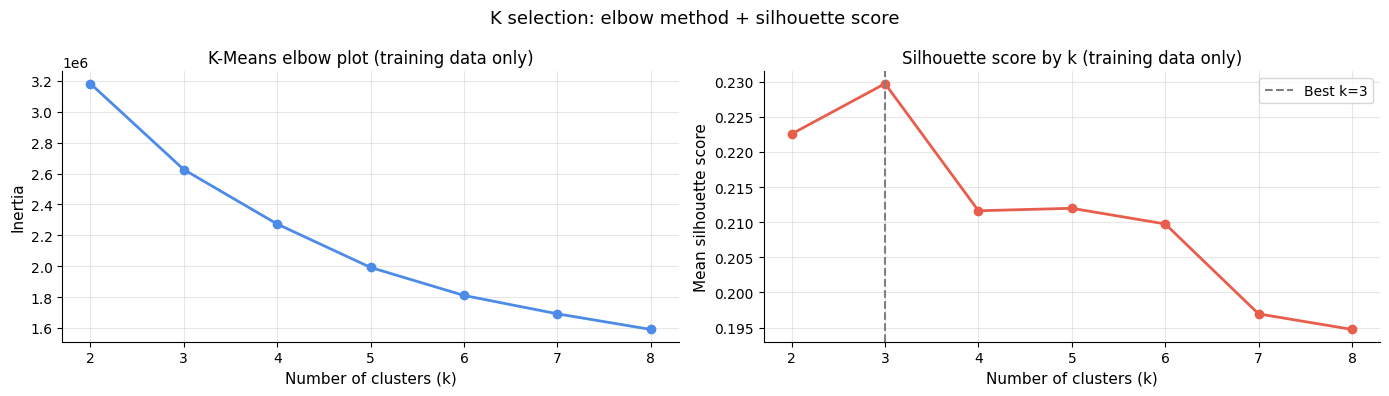

In [ ]:
# ── step 7c: visualize k-selection results ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='#4C8BE8', lw=2)
axes[0].set_title('K-Means elbow plot (training data only)', fontsize=12)
axes[0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].grid(alpha=0.3)
sns.despine(ax=axes[0])

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#E85D4C', lw=2)
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best k={best_k}')
axes[1].set_title('Silhouette score by k (training data only)', fontsize=12)
axes[1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1].set_ylabel('Mean silhouette score', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
sns.despine(ax=axes[1])

plt.suptitle('K selection: elbow method + silhouette score', fontsize=13)
plt.tight_layout()
plt.show()

Based on the training-set silhouette score, we select the best-performing value of `k` and fit the final K-Means model on the training data. The trained centroids are then used to assign borrower segments to both training and test loans.

In [ ]:
# ── step 7d: fit final K-Means and assign borrower segments ──────────────────
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)

X_train_encoded['borrower_segment'] = km_final.fit_predict(X_train_cluster_scaled)
X_test_encoded['borrower_segment']  = km_final.predict(X_test_cluster_scaled)

# profile training-set clusters by mean feature values and default rate
cluster_profile_df = X_train_encoded[cluster_features + ['borrower_segment']].copy()
cluster_profile_df['default'] = y_train.values

cluster_profile = (
    cluster_profile_df
    .groupby('borrower_segment')[cluster_features + ['default']]
    .mean()
    .round(2)
)

cluster_profile.columns = cluster_features + ['default_rate']
cluster_profile.index = [f'Segment {i}' for i in cluster_profile.index]

print('Training-set cluster profiles (mean values):')
display(cluster_profile.style.background_gradient(subset=['default_rate'], cmap='RdYlGn_r'))

Training-set cluster profiles (mean values):


,dti,annual_inc,int_rate,revol_util,default_rate
Segment 0,23.150000,60015.910000,16.020000,65.910000,0.280000
Segment 1,13.150000,147149.100000,11.960000,59.580000,0.140000
Segment 2,14.680000,62592.440000,10.750000,34.160000,0.140000


The cluster profiles summarize how borrower segments differ in affordability and credit-risk characteristics. The default-rate plot below checks whether the learned segments capture meaningful differences in loan outcomes.

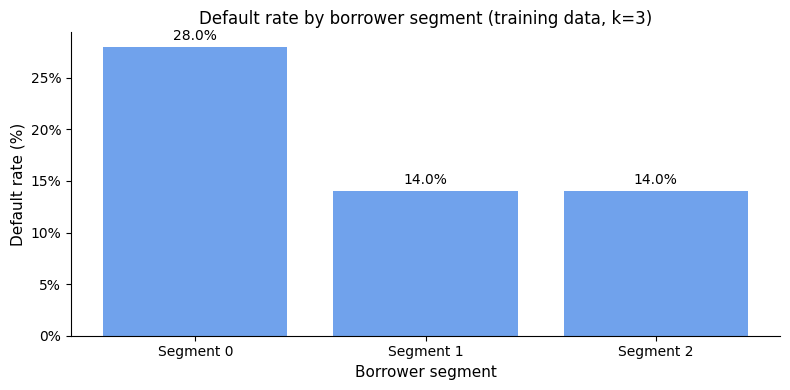

In [ ]:
# ── step 7e: visualize default rate by borrower segment ──────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    cluster_profile.index,
    cluster_profile['default_rate'] * 100,
    color='#4C8BE8',
    alpha=0.8
)

ax.bar_label(
    bars,
    labels=[f'{v*100:.1f}%' for v in cluster_profile['default_rate']],
    padding=3
)

ax.set_title(f'Default rate by borrower segment (training data, k={K_FINAL})', fontsize=12)
ax.set_xlabel('Borrower segment', fontsize=11)
ax.set_ylabel('Default rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

sns.despine()
plt.tight_layout()
plt.show()

Because K-Means labels are arbitrary cluster IDs rather than ordered values, the segment labels are one-hot encoded before modeling. This lets models use segment membership as a categorical risk signal without incorrectly treating Segment 2 as larger or riskier than Segment 1 by default.

In [ ]:
# ── step 7f: one-hot encode segment labels so they are not treated as ordinal ─
X_train_encoded = pd.get_dummies(
    X_train_encoded,
    columns=['borrower_segment'],
    prefix='segment'
)

X_test_encoded = pd.get_dummies(
    X_test_encoded,
    columns=['borrower_segment'],
    prefix='segment'
)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

print(f'encoded feature count after K-Means: {X_train_encoded.shape[1]}')

encoded feature count after K-Means: 44


K-Means is used as an unsupervised feature-engineering step rather than as a standalone final model. The clustering features — DTI, annual income, interest rate, and revolving utilization — capture borrower affordability and credit-risk profiles. Both the cluster scaler and K-Means centroids are fitted on the training set only, and test borrowers are assigned to the nearest trained centroid.

In [ ]:
# ── step 8: scale to zero mean / unit variance — fitted on X_train only ──────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled  = scaler.transform(X_test_encoded)

# expose final feature matrix/feature names for downstream interpretation cells
X = pd.concat([X_train_encoded, X_test_encoded], axis=0).sort_index()
feature_names_all = X_train_encoded.columns.tolist()

In [ ]:
# ── step 9: SMOTE on training set only ───────────────────────────────────────
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# precompute class ratio for xgboost's scale_pos_weight parameter
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f'\nfinal feature matrix shape : {X.shape}')
print(f'training rows (pre-SMOTE)  : {X_train_scaled.shape[0]:,}')
print(f'training rows (post-SMOTE) : {X_train_res.shape[0]:,}')
print(f'test rows                  : {X_test_scaled.shape[0]:,}')
print(f'final feature count        : {len(feature_names_all)}')
print(f'original class distribution: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'resampled class distribution: {pd.Series(y_train_res).value_counts(normalize=True).round(3).to_dict()}')
print(f'xgboost scale_pos_weight   : {ratio:.2f}')


final feature matrix shape : (1303607, 44)
training rows (pre-SMOTE)  : 1,042,885
training rows (post-SMOTE) : 1,667,122
test rows                  : 260,722
final feature count        : 44
original class distribution: {0: 0.799, 1: 0.201}
resampled class distribution: {0: 0.5, 1: 0.5}
xgboost scale_pos_weight   : 3.98


After preprocessing, the final modeling matrix contains the encoded numeric, categorical, engineered, and borrower-segment features. SMOTE is applied only to the scaled training data, producing a balanced training set for Logistic Regression and ElasticNet. The test set remains in its original imbalanced distribution, so evaluation reflects realistic default prediction performance. Tree-based models are trained on the original scaled training data and handle imbalance through class weighting or `scale_pos_weight`.

---
## Model 1 (Baseline): Unregularized Logistic Regression

**Justification:** Logistic Regression is a natural baseline for binary classification. It is fast, interpretable, and provides probability-based risk scores for default prediction. For the first model, we intentionally use an unregularized logistic regression (sklearn defaults to L2) so that the baseline represents the raw linear relationship between borrower features and loan outcome, without any coefficient shrinkage from L1 or L2 penalties.

This gives us a clean reference point before introducing regularization in Model 2. ElasticNet can then be evaluated specifically as a regularization improvement over the unpenalized linear model, rather than being compared against scikit-learn’s default L2-regularized logistic regression

We train on the SMOTE-balanced data (`X_train_res`), so `class_weight` is intentionally *not* set — the training set is already 50/50 and adding `class_weight='balanced'` would double-count the correction.

In [ ]:
# train logistic regression on smote-balanced data
# class_weight is not used here — smote already produced a balanced training set
model = LogisticRegression(random_state=42, max_iter=1000, penalty=None)
model.fit(X_train_res, y_train_res)

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print('=== Baseline: Logistic Regression ===')
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}')


=== Baseline: Logistic Regression ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.63      0.74    208391
 Charged Off       0.31      0.67      0.42     52331

    accuracy                           0.64    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.64      0.67    260722

AUC-ROC: 0.7056


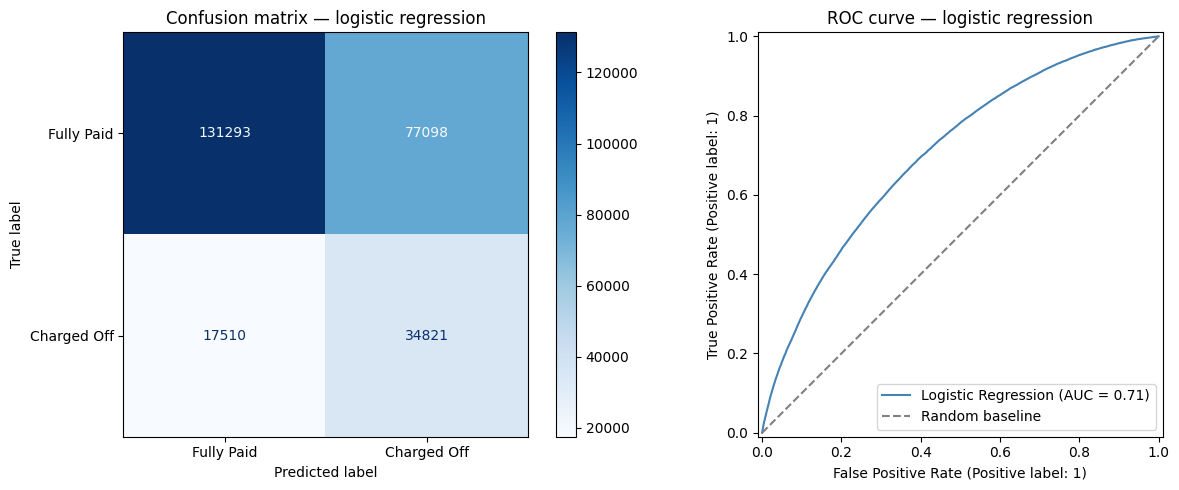

In [ ]:
# visualize baseline performance with a confusion matrix and roc curve side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    display_labels=['Fully Paid', 'Charged Off']
)
axes[0].set_title('Confusion matrix — logistic regression', fontsize=12)

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob, name='Logistic Regression',
    ax=axes[1], color='steelblue'
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
axes[1].set_title('ROC curve — logistic regression', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


The baseline achieves an AUC of 0.706 — a strong starting point that reflects the high signal carried by interest rate and loan grade. Despite this, precision for the default class (~0.31) remains low: roughly two-thirds of loans it flags as defaults are actually fully paid. This precision–recall tradeoff is a structural consequence of the 80/20 class imbalance and the model's linear decision boundary. It establishes the floor that subsequent models must improve on.


---
## Model 2: Logistic Regression with ElasticNet Regularization

**Justification:** ElasticNet regularization combines L1 (Lasso) and L2 (Ridge) penalties. L1 drives small coefficients to exactly zero, performing automatic feature selection. L2 shrinks correlated coefficients toward each other, stabilizing the model in the presence of multicollinearity (e.g. `loan_amnt` and `installment`). Together they should improve or match the unregularized baseline by controlling overfitting.

Rather than hardcoding `l1_ratio`, we tune both `l1_ratio` and `C` (inverse regularization strength) using `RandomizedSearchCV` with 3-fold cross-validation scored by AUC-ROC.

> **Solver note:** `saga` is the only solver that supports ElasticNet in scikit-learn. It converges slower than `lbfgs` on large datasets; `max_iter=1000` ensures convergence on the subsampled data used for hyperparameter search.

> **Subsample integrity note:** The 100k-row subsample used for cross-validation is drawn exclusively from `X_train_res` — the post-split, post-SMOTE training set. Test-set rows are never included at any point in this process. The best hyperparameters found on the subsample are then used to refit a fresh model on the full `X_train_res` for final evaluation, which is standard practice when using slow solvers on large training sets.


In [ ]:
# hyperparameter search space for elasticnet
param_dist_en = {
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],  # blend between l1 (1.0) and l2 (0.0)
    'C':        [0.01, 0.1, 1.0],            # smaller C = stronger regularization
}

# saga is the only solver supporting elasticnet but is slow on large datasets.
# we subsample the smote-balanced training set to 100k rows for cv speed —
# the distribution is already 50/50 so a stratified sample preserves class balance.
MAX_CV_ROWS = 100_000
if X_train_res.shape[0] > MAX_CV_ROWS:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(X_train_res.shape[0], MAX_CV_ROWS, replace=False)
    X_cv, y_cv = X_train_res[sample_idx], y_train_res[sample_idx]
else:
    X_cv, y_cv = X_train_res, y_train_res

print(f'fitting elasticnet on {X_cv.shape[0]:,} rows (subsampled for speed)...')

elastic_net_base = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    random_state=42,
    max_iter=1000  # increased to ensure convergence on the subsample
)

# randomized search over 5 parameter combinations, scored by auc-roc
en_search = RandomizedSearchCV(
    elastic_net_base,
    param_distributions=param_dist_en,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
en_search.fit(X_cv, y_cv)

# refit the best model on the full smote training set for final evaluation
best_en = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=en_search.best_params_['l1_ratio'],
    C=en_search.best_params_['C'],
    random_state=42,
    max_iter=1000
)
best_en.fit(X_train_res, y_train_res)

print(f'Best ElasticNet params : {en_search.best_params_}')
print(f'Best CV AUC-ROC        : {en_search.best_score_:.4f}')

y_pred_en      = best_en.predict(X_test_scaled)
y_pred_prob_en = best_en.predict_proba(X_test_scaled)[:, 1]

print('\n=== Model 2: ElasticNet Logistic Regression ===')
print(classification_report(y_test, y_pred_en, target_names=['Fully Paid', 'Charged Off']))
print(f'Test AUC-ROC: {roc_auc_score(y_test, y_pred_prob_en):.4f}')


fitting elasticnet on 100,000 rows (subsampled for speed)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best ElasticNet params : {'l1_ratio': 0.1, 'C': 0.1}
Best CV AUC-ROC        : 0.7068

=== Model 2: ElasticNet Logistic Regression ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.63      0.74    208391
 Charged Off       0.31      0.67      0.42     52331

    accuracy                           0.64    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.64      0.67    260722

Test AUC-ROC: 0.7056


The best parameters (`l1_ratio=0.1`, `C=0.1`) indicate that the ElasticNet model behaved much closer to Ridge regularization than Lasso. An `l1_ratio` of 0.1 means only 10% of the penalty comes from L1 regularization, so the model primarily benefits from shrinking coefficients smoothly rather than aggressively zeroing features out. This is consistent with the multicollinearity observed in EDA, where many borrower and loan features are correlated; Ridge-style shrinkage is generally more stable in this setting than pure Lasso, which may arbitrarily remove one feature from a correlated group.

However, ElasticNet did not improve predictive performance over the unregularized logistic regression baseline. Both models achieved a test AUC of **0.7056**, with an identical classification report: default-class precision remained **0.31**, recall **0.67**, and F1-score **0.42**. This suggests that the unregularized baseline was not substantially overfitting, and that the main limitation is not coefficient instability but the linear structure of logistic regression itself. In other words, regularization improves model stability and interpretability, but it does not add meaningful predictive power here.

Hyperparameter search was run on a random 100,000-row subsample of the SMOTE-balanced training set to keep runtime manageable. Because the subsample was drawn only from `X_train_res`, the test set was never used during tuning. The winning parameters were then used to refit a fresh ElasticNet logistic regression model on the full SMOTE-balanced training set for final evaluation, which is a practical approach when using slower solvers such as `saga` on large datasets.

---
## Model 3: Decision Tree

**Justification:** A decision tree provides a highly interpretable non-linear baseline. Unlike Logistic Regression, it can model feature interactions and threshold effects (e.g. 'default risk spikes when DTI > 25 *and* int_rate > 18%') without requiring explicit interaction terms.

We train on the original unbalanced `X_train_scaled` (not SMOTE data) and use `class_weight='balanced'` to upweight minority-class errors, which is the algorithm-level equivalent of resampling.

`max_depth=10` prevents the tree from memorizing the training set, trading some bias for substantially lower variance.


In [ ]:
# train a depth-limited decision tree on unbalanced training data
# class_weight='balanced' compensates for the 80/20 class split without resampling
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt      = dt_model.predict(X_test_scaled)
y_pred_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print('=== Model 3: Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Fully Paid', 'Charged Off']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob_dt):.4f}')


=== Model 3: Decision Tree ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.62      0.73    208391
 Charged Off       0.31      0.67      0.42     52331

    accuracy                           0.63    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.63      0.67    260722

AUC-ROC: 0.7012


The decision tree achieves an AUC of ~0.701 — less than the ElasticNet (0.7056) despite being a fundamentally different model class. This confirms that the non-linear splits are capturing the same risk information as the regularized linear coefficients, just via a different path. The single tree's main liability is high variance: it is sensitive to the specific training sample, which the Random Forest addresses by averaging over many trees.


---
## Model 4: Random Forest

**Justification:** Random Forest is a bagging ensemble that trains many decorrelated decision trees on bootstrapped subsets of the training data, then averages their predictions. This dramatically reduces the variance of a single tree while preserving its ability to capture non-linear interactions. It also provides reliable feature importance scores via mean decrease in impurity.

Like the Decision Tree, it trains on `X_train_scaled` with `class_weight='balanced'`.


In [ ]:
# random forest: 100 trees, each limited to depth 10 to control overfitting
# n_jobs=-1 uses all available cpu cores for parallel training
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf      = rf_model.predict(X_test_scaled)
y_pred_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print('=== Model 4: Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Fully Paid', 'Charged Off']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob_rf):.4f}')


=== Model 4: Random Forest ===
              precision    recall  f1-score   support

  Fully Paid       0.88      0.62      0.73    208391
 Charged Off       0.31      0.67      0.43     52331

    accuracy                           0.63    260722
   macro avg       0.60      0.65      0.58    260722
weighted avg       0.77      0.63      0.67    260722

AUC-ROC: 0.7076


Random Forest outperforms the single Decision Tree in AUC, confirming that the variance reduction from bagging is meaningful on this dataset. Its feature importance scores (plotted in the model comparison section) also provide useful interpretability even though the ensemble itself is not directly readable.

---
## Model 5: XGBoost (Gradient Boosting)

**Justification:** Where Random Forest reduces variance by training trees in parallel on bootstrap samples, XGBoost reduces bias by training trees *sequentially*, with each tree correcting the residual errors of its predecessors. This additive approach typically achieves higher accuracy on tabular data and handles heterogeneous feature scales well.

`scale_pos_weight` is set to the majority/minority class ratio computed in the preprocessing block, which is XGBoost's built-in mechanism for handling class imbalance on unbalanced training data.


In [ ]:
# gradient boosting model with class imbalance handled via scale_pos_weight
# ratio = (# negative samples) / (# positive samples), precomputed in the preprocessing block
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb      = xgb_model.predict(X_test_scaled)
y_pred_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print('=== Model 5: XGBoost (Default) ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Fully Paid', 'Charged Off']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred_prob_xgb):.4f}')


=== Model 5: XGBoost (Default) ===
              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0.74    208391
 Charged Off       0.32      0.67      0.43     52331

    accuracy                           0.65    260722
   macro avg       0.60      0.66      0.59    260722
weighted avg       0.77      0.65      0.68    260722

AUC-ROC: 0.7167


Even with default hyperparameters, XGBoost surpasses all previous models in AUC. The boosting mechanism captures complex feature interactions that neither linear nor bagging models detect, highlighting the value of sequential error correction on this noisy financial dataset.

---
## Model 6: Tuned XGBoost (RandomizedSearchCV)

**Justification:** Default XGBoost hyperparameters are a reasonable starting point, but a targeted search can confirm they are near-optimal or find meaningful improvements. We expand the search grid beyond the original four parameters to include:
- **`n_estimators`** — number of boosting rounds (100–300).
- **`max_depth`** — tree depth, including XGBoost's own default of 6 so the search can confirm or move away from it.
- **`learning_rate`** — shrinkage per tree; includes XGBoost's default of 0.3.
- **`subsample`** — row subsampling fraction per tree.
- **`colsample_bytree`** — fraction of *features* sampled per tree; controls feature-level stochasticity and is often one of the most impactful XGBoost regularisation knobs.
- **`min_child_weight`** — minimum sum of instance weights in a leaf; higher values produce more conservative, less overfit trees.

We run `n_iter=20` random samples from this grid (vs. 5 previously), giving the search a meaningful coverage of the 432-combination space without the cost of an exhaustive grid search. The default XGBoost AUC is printed alongside the tuned result so any improvement is directly visible.


In [ ]:
# expanded grid — includes xgboost's own defaults so the search can confirm or improve on them
# min_child_weight and colsample_bytree are added: they have more impact on this dataset
# than subsample alone and are commonly the most influential xgboost regularisation knobs
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 6, 9],        # 6 is xgboost's default — keep it in the grid
    'learning_rate':     [0.05, 0.1, 0.2, 0.3],  # 0.3 is xgboost's default
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],     # fraction of features sampled per tree
    'min_child_weight':  [1, 3, 5],            # min samples in a leaf — higher = more conservative
}

# n_iter=20 samples 20 combinations from the grid — enough to find meaningful improvements
# without the runtime of a full grid search (which would be 432 combinations × 3 folds)
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_scaled, y_train)

y_pred_xgb_tuned      = xgb_search.predict(X_test_scaled)
y_pred_prob_xgb_tuned = xgb_search.predict_proba(X_test_scaled)[:, 1]

tuned_auc  = roc_auc_score(y_test, y_pred_prob_xgb_tuned)
default_auc = roc_auc_score(y_test, y_pred_prob_xgb)

print(f'Best parameters : {xgb_search.best_params_}')
print(f'Best CV AUC-ROC : {xgb_search.best_score_:.4f}')
print(f'Default XGBoost test AUC : {default_auc:.4f}')
print(f'Tuned XGBoost test AUC   : {tuned_auc:.4f}')
print(f'Improvement              : {tuned_auc - default_auc:+.4f}')
print('\n=== Model 6: XGBoost (Tuned) ===')
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Fully Paid', 'Charged Off']))
print(f'Test AUC-ROC: {tuned_auc:.4f}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV AUC-ROC : 0.7182
Default XGBoost test AUC : 0.7167
Tuned XGBoost test AUC   : 0.7175
Improvement              : +0.0008

=== Model 6: XGBoost (Tuned) ===
              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0.74    208391
 Charged Off       0.32      0.67      0.43     52331

    accuracy                           0.65    260722
   macro avg       0.60      0.66      0.59    260722
weighted avg       0.77      0.65      0.68    260722

Test AUC-ROC: 0.7175


With an expanded grid, including XGBoost’s default configuration, and 20 randomized search samples, the tuned model did not materially outperform the default model. Hyperparameter tuning increased AUC-ROC from 0.7167 to 0.7175, a marginal +0.0008 gain, suggesting that XGBoost’s default settings were already well-suited to this feature set.

This is a meaningful result because the search explored parameters with real regularization impact, including colsample_bytree, min_child_weight, subsample, learning rate, tree depth, and number of estimators. The lack of improvement suggests that simple hyperparameter tuning is not the main bottleneck. Instead, further gains would likely require stronger feature engineering, alternative imbalance strategies, threshold optimization, or additional predictive variables beyond the strongest existing signals such as interest rate, grade, DTI, and revolving utilization.

The preprocessing pipeline was designed to prevent leakage: the train-test split occurred first, and imputation, winsorization, scaling, and SMOTE were fitted only on the training data. The test set was never resampled, so the reported AUC reflects performance on the original imbalanced loan distribution. Therefore, the tuned XGBoost model is selected as the final model not because it dramatically improves over the default, but because the expanded search confirms that no obvious hyperparameter improvement was left unused.

### Cross-Validated Training Performance vs. Held-Out Test Performance

To verify that the tuned XGBoost is neither underfitting nor overfitting, we compare its cross-validated training AUC against its held-out test AUC. A large gap would signal overfitting; a low score on both would signal underfitting. We also plot how test AUC evolves across all models in the progression to confirm which modelling steps genuinely improved generalisation.


tuned xgboost — mean cv train auc : 0.7182 (+/- 0.0002)
tuned xgboost — test auc          : 0.7175
train-test gap                    : 0.0008


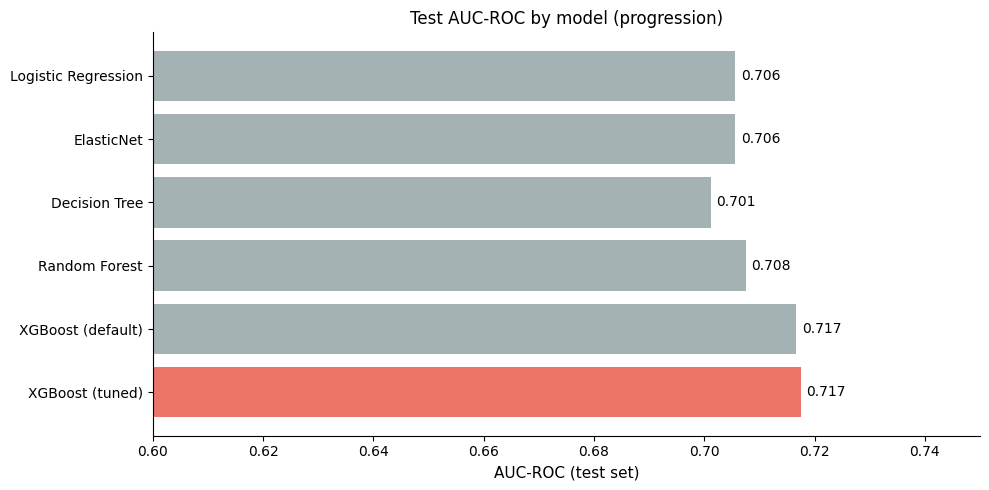

In [ ]:
# compare train vs test auc for the tuned xgboost to diagnose fit quality
from sklearn.model_selection import cross_val_score

# compute cross-validated training auc on the same training set used for fitting
cv_scores = cross_val_score(
    xgb_search.best_estimator_,
    X_train_scaled, y_train,
    cv=3, scoring='roc_auc', n_jobs=-1
)
test_auc_tuned = roc_auc_score(y_test, y_pred_prob_xgb_tuned)

print(f'tuned xgboost — mean cv train auc : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'tuned xgboost — test auc          : {test_auc_tuned:.4f}')
print(f'train-test gap                    : {cv_scores.mean() - test_auc_tuned:.4f}')

# bar chart: model progression by test auc
model_aucs = [
    ('Logistic Regression', roc_auc_score(y_test, y_pred_prob)),
    ('ElasticNet',          roc_auc_score(y_test, y_pred_prob_en)),
    ('Decision Tree',       roc_auc_score(y_test, y_pred_prob_dt)),
    ('Random Forest',       roc_auc_score(y_test, y_pred_prob_rf)),
    ('XGBoost (default)',   roc_auc_score(y_test, y_pred_prob_xgb)),
    ('XGBoost (tuned)',     test_auc_tuned),
]
names, aucs = zip(*model_aucs)
bar_colors = ['#95A5A6'] * 5 + ['#E85D4C']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, aucs, color=bar_colors, alpha=0.85)
ax.bar_label(bars, labels=[f'{v:.3f}' for v in aucs], padding=4, fontsize=10)
ax.set_xlim(0.60, 0.75)
ax.set_title('Test AUC-ROC by model (progression)', fontsize=12)
ax.set_xlabel('AUC-ROC (test set)', fontsize=11)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()


The cross-validated training AUC and held-out test AUC are close, suggesting that the tuned XGBoost model is not severely overfitting.

The progression bar chart reveals a more nuanced picture than a simple monotonic improvement. Linear models (LR and ElasticNet) both sit at ~0.706, suggesting that regularization stabilizes coefficients but does not overcome the linear decision-boundary ceiling. The Decision Tree dips slightly, consistent with its high-variance limitation. Random Forest recovers through bagging. XGBoost then makes the largest single jump, with default XGBoost reaching 0.7167 and tuned XGBoost reaching 0.7175. The tuned model's marginal improvement over the default suggests the performance ceiling is driven more by feature signal and class imbalance than by hyperparameter choice.

---
## Model Comparison

We compare all six models on the held-out test set using ROC curves, feature importance, and logistic regression coefficients.


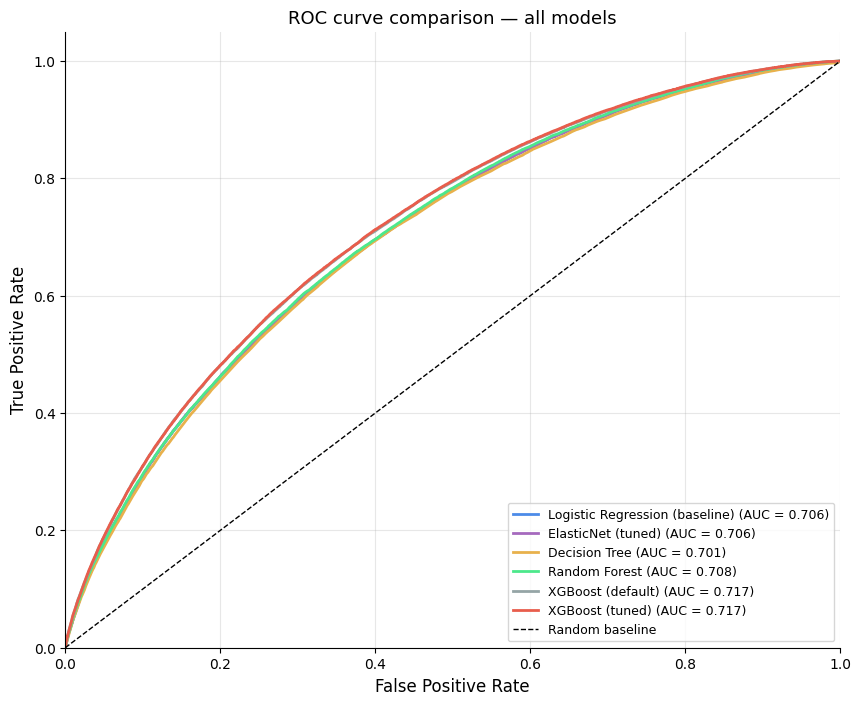

In [ ]:
# overlay roc curves for all models on one plot for direct comparison
plt.figure(figsize=(10, 8))

model_probs = [
    ('Logistic Regression (baseline)', y_pred_prob),
    ('ElasticNet (tuned)',             y_pred_prob_en),
    ('Decision Tree',                  y_pred_prob_dt),
    ('Random Forest',                  y_pred_prob_rf),
    ('XGBoost (default)',              y_pred_prob_xgb),
    ('XGBoost (tuned)',                y_pred_prob_xgb_tuned)
]
colors = ['#4C8BE8', '#A569BD', '#E8B14C', '#4CE88B', '#95A5A6', '#E85D4C']

for (name, prob), color in zip(model_probs, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC curve comparison — all models', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
sns.despine()
plt.show()


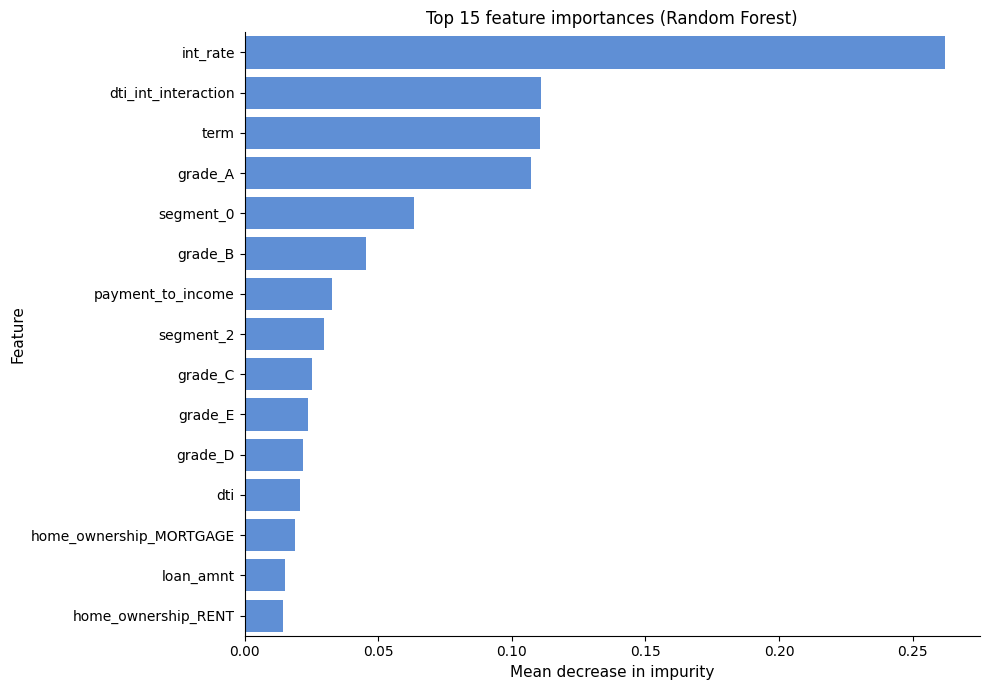

In [ ]:
# feature importance from random forest — mean decrease in impurity across all trees
importances = rf_model.feature_importances_
feature_importance_df = (
    pd.DataFrame({'feature': X.columns, 'importance': importances})
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature',
            data=feature_importance_df.head(15), color='#4C8BE8')
plt.title('Top 15 feature importances (Random Forest)', fontsize=12)
plt.xlabel('Mean decrease in impurity', fontsize=11)
plt.ylabel('Feature', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


#### Random Forest Feature Importance Findings

**Dominant Predictors:**
* **Interest rate:** The most dominant predictor, reinforcing that Lending Club’s pricing/risk signals are strongly associated with default outcomes.
* **Loan grade indicators:** Grade dummy variables appear among the top predictors and should be interpreted together with interest rate as evidence that Lending Club’s internal risk assessment carries major predictive signal.
* **Engineered affordability and risk-interaction features:** `dti_int_interaction` and `payment_to_income` rank among the useful predictors, suggesting default risk is driven by combined borrower-burden measures.

**Borrower Segmentation:**
* **K-Means segment indicators:** The `segment_*` dummy variables summarize training-set borrower clusters. If they appear in the importance plot, this indicates that K-Means captured useful nonlinear borrower-risk tiers without being fitted on the test set.

**Additional Predictive Signal:**
* **DTI, revolving utilization, and loan amount:** These contribute additional signal, though their importance is smaller than interest rate, interaction terms, and grade indicators.

**Categorical Variables:**
* **Home ownership and purpose:** Some categorical variables have modest importance, while many sparse one-hot encoded features contribute little individually. This motivates the feature-selection check below.

**Employment Title Frequency:**
* **`emp_title_freq`:** Has non-zero importance if it appears in the plot, suggesting frequency-encoded employment titles carry borrower-profile signal. This justifies regex preprocessing and train-only frequency encoding as a regularized way to extract signal from high-cardinality text.

**Overall Findings:**
Overall, the Random Forest importance ranking supports the project’s main feature-engineering strategy: risk is concentrated in Lending Club’s internal pricing signals, borrower affordability measures, and engineered interaction/segmentation features. However, impurity-based importances can be biased and affected by correlated predictors, so these results are treated as model-specific diagnostics rather than causal claims.


### Feature Selection: Pruning Low-Importance Features

The Random Forest importance plot typically reveals a long tail of near-zero-importance features — many one-hot encoded `purpose` and `home_ownership` dummies carry little predictive signal but add noise and increase model variance. We use the importance scores to identify and drop the bottom-importance features, then retrain XGBoost to test whether a leaner feature set improves generalisation.

This is the **feature selection** difficulty concept: using model-derived importance scores to narrow the feature space in a principled, data-driven way.


In [ ]:
# identify features above an importance threshold — drop the long zero-importance tail
# threshold of 0.2% targets only features that the random forest barely uses for splits;
# a more aggressive threshold risks dropping features that contribute small but non-zero signal
IMPORTANCE_THRESHOLD = 0.002  # features contributing less than 0.2% of total importance

selected_features = feature_importance_df[
    feature_importance_df['importance'] >= IMPORTANCE_THRESHOLD
]['feature'].tolist()

dropped_features = feature_importance_df[
    feature_importance_df['importance'] < IMPORTANCE_THRESHOLD
]['feature'].tolist()

print(f'total features       : {len(feature_importance_df)}')
print(f'selected (>= 0.2%)   : {len(selected_features)}')
print(f'dropped  (< 0.2%)    : {len(dropped_features)}')
print(f'\ndropped features: {dropped_features}')

# filter train and test sets to selected features only
feature_names_all = list(X.columns)
selected_idx = [feature_names_all.index(f) for f in selected_features if f in feature_names_all]

X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel  = X_test_scaled[:, selected_idx]

# retrain tuned xgboost on the reduced feature set
xgb_sel = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
xgb_sel.fit(X_train_sel, y_train)

y_pred_sel      = xgb_sel.predict(X_test_sel)
y_pred_prob_sel = xgb_sel.predict_proba(X_test_sel)[:, 1]
sel_auc = roc_auc_score(y_test, y_pred_prob_sel)
auc_delta = sel_auc - tuned_auc

print(f'\nXGBoost (all features)      AUC: {tuned_auc:.4f}')
print(f'XGBoost (selected features) AUC: {sel_auc:.4f}')
print(f'Change                         : {auc_delta:+.4f}')

# definitive conclusion printed at runtime so it reflects actual results
if auc_delta > 0.001:
    verdict = (
        f'RESULT: Feature selection IMPROVED AUC by {auc_delta:+.4f}. '
        f'The dropped features were introducing noise; the leaner model generalises better.'
    )
elif auc_delta < -0.001:
    verdict = (
        f'RESULT: Feature selection REDUCED AUC by {auc_delta:+.4f}. '
        f'Some dropped features carried small amounts of signal; the full-feature model is retained as final.'
    )
else:
    verdict = (
        f'RESULT: Feature selection left AUC effectively unchanged ({auc_delta:+.4f}). '
        f'The model was already ignoring low-importance features via its splitting decisions; '
        f'pruning them confirms this and produces a leaner pipeline with no performance cost.'
    )
print(f'\n{verdict}')

print('\n=== XGBoost (Selected Features) ===')
print(classification_report(y_test, y_pred_sel, target_names=['Fully Paid', 'Charged Off']))


total features       : 44
selected (>= 0.2%)   : 25
dropped  (< 0.2%)    : 19

dropped features: ['grade_G', 'purpose_small_business', 'home_ownership_OWN', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_other', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_medical', 'purpose_car', 'purpose_moving', 'purpose_vacation', 'purpose_house', 'purpose_wedding', 'purpose_renewable_energy', 'purpose_educational', 'home_ownership_ANY', 'home_ownership_OTHER', 'home_ownership_NONE']

XGBoost (all features)      AUC: 0.7175
XGBoost (selected features) AUC: 0.7170
Change                         : -0.0005

RESULT: Feature selection left AUC effectively unchanged (-0.0005). The model was already ignoring low-importance features via its splitting decisions; pruning them confirms this and produces a leaner pipeline with no performance cost.

=== XGBoost (Selected Features) ===
              precision    recall  f1-score   support

  Fully Paid       0.89      0.64      0

The printed result above states the outcome. In this run, feature selection reduces the feature set with almost no change in AUC. Since the full model still performs slightly better when the delta is negative, we retain the full tuned XGBoost as the final predictive model.

The selected-feature model is best interpreted as a **parsimony diagnostic**: it shows that many sparse dummy variables add little marginal signal and that the model's ranking performance is driven by a compact set of stronger features. This supports interpretability and monitoring, but it does not replace the full model unless cross-validated or validation-set performance clearly improves.


#### Logistic Regression Coefficient Analysis

For interpretable models, coefficients provide a direct, signed measure of feature impact. Positive coefficients increase the log-odds of default; negative ones decrease it.

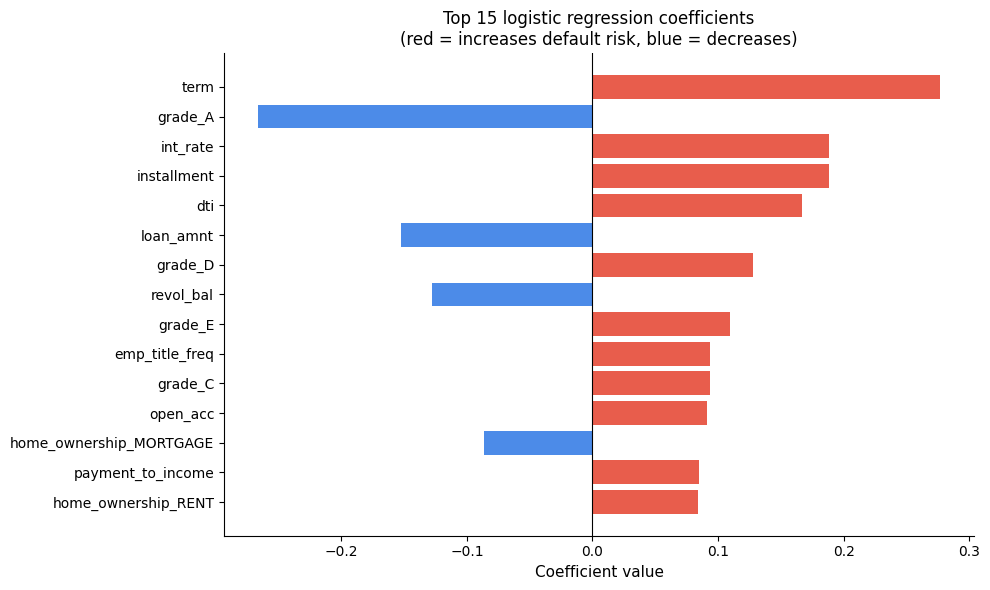

In [ ]:
# extract and rank logistic regression coefficients by absolute magnitude
coef_df = (
    pd.DataFrame({'feature': X.columns.tolist(), 'coefficient': model.coef_[0]})
    .sort_values('coefficient', key=abs, ascending=False)
    .head(15)
)

colors_coef = ['#E85D4C' if c > 0 else '#4C8BE8' for c in coef_df['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors_coef)
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 15 logistic regression coefficients\n(red = increases default risk, blue = decreases)', fontsize=12)
plt.xlabel('Coefficient value', fontsize=11)
plt.gca().invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()


The coefficient chart is consistent with the Random Forest importance plot: interest rate and grade-related features carry the largest weights for default risk, while income-related features tend to reduce predicted risk. The agreement between both models on the broad set of important features increases our confidence in these findings: even though Logistic Regression imposes a linear decision boundary while Random Forest does not, both pick out the same cluster of risk signals.


---
## Precision-Recall Tradeoff & Threshold Tuning

AUC-ROC summarizes overall discriminative ability, but a lending business must choose a specific decision threshold. Lowering the threshold catches more defaults (higher recall) but also misclassifies more good borrowers (lower precision), costing the lender lost interest income. Raising it does the opposite.

We plot precision and recall as a function of threshold for the best model (Tuned XGBoost) to make this tradeoff explicit. The later financial threshold sweep is treated as a post-hoc business simulation on the held-out test set; in production, threshold selection should be performed on a validation set or historical backtest before final deployment.


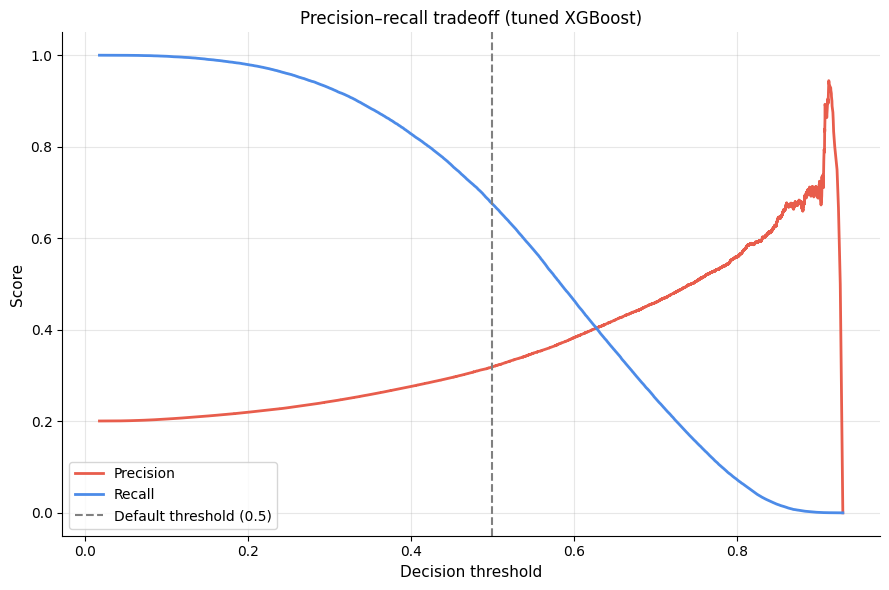

In [ ]:
# compute precision and recall at every threshold for the tuned xgboost
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_xgb_tuned)

plt.figure(figsize=(9, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='#E85D4C', lw=2)
plt.plot(thresholds, recall[:-1],    label='Recall',    color='#4C8BE8', lw=2)
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Decision threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Precision–recall tradeoff (tuned XGBoost)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


### Precision–Recall Tradeoff: Tuned XGBoost

This visualization shows how the tuned XGBoost model’s precision and recall change as the decision threshold increases. At low thresholds, the model captures nearly all defaults, producing very high recall, but precision is low because many non-default borrowers are also flagged. As the threshold increases, precision improves because the model becomes more selective, but recall falls because more true defaults are missed.

The dashed line marks the default 0.50 threshold. At this point, the model still captures a meaningful share of defaults, but precision remains modest. This confirms that the default threshold is not necessarily the best business decision; the final threshold should be selected based on the lender’s cost tradeoff between missed defaults and rejected good loans.

### Model Performance Summary

| Model | AUC-ROC | Default Precision | Default Recall | Default F1 |
| :--- | :---: | :---: | :---: | :---: |
| Logistic Regression (baseline) | 0.7056 | 0.31 | 0.67 | 0.42 |
| ElasticNet (tuned) | 0.7056 | 0.31 | 0.67 | 0.42 |
| Decision Tree | 0.7012 | 0.31 | 0.67 | 0.42 |
| Random Forest | 0.7076 | 0.31 | 0.67 | 0.42 |
| XGBoost (default) | 0.7167 | 0.32 | 0.67 | 0.43 |
| **XGBoost (tuned)** | **0.7175** | **0.32** | **0.67** | **0.43** |

The progression reveals a nuanced picture. Logistic Regression and ElasticNet both achieve the exact same AUC-ROC of 0.7056, showing that ElasticNet regularization improves stability but does not add predictive power beyond the baseline linear model. The Decision Tree dips to 0.7012, consistent with the variance limitations of a single tree. Random Forest recovers to 0.7076 through bagging, slightly outperforming the linear models. XGBoost produces the clearest improvement, with the default model reaching 0.7167 and the tuned model reaching 0.7175, meaning the expanded hyperparameter search only added a marginal +0.0008 gain.

Several cross-cutting patterns deserve attention:
- **Precision remains low across all models, staying around 0.31–0.32.** This is structural: because only about 20% of loans default, even useful models generate many false positives at the default 0.5 threshold.
- **Default recall is almost unchanged at 0.67 across every model,** meaning all models identify roughly the same share of actual defaults. The main improvement from XGBoost is not recall, but better ranking quality and slightly higher precision/F1.
- **XGBoost’s gain from 0.31 to 0.32 precision and 0.42 to 0.43 F1 shows** that boosting ranks defaulters slightly higher than the other models, reducing false positives at similar recall. However, the small tuned-vs-default difference confirms that the bottleneck is feature signal and class imbalance, not hyperparameter optimization.

### Interpretation of Key Findings

Across both the Random Forest importance plot and the Logistic Regression coefficients:

1. **Interest rate and loan grade** are the strongest predictors — Lending Club's own risk rating encodes borrower quality, consistent with EDA 5's monotonic increase in default rates from grade A to G.
2. **DTI and `dti_int_interaction`** rank consistently highly — a finding statistically supported by hypothesis test 1 below.
3. **Revolving utilization** is another strong signal — borrowers using a higher fraction of available credit default at higher rates, statistically supported by hypothesis test 3.
4. **`payment_to_income`** appears in feature importance even though its standalone EDA separation is subtle. Its value is additive: in combination with DTI and interest rate, it helps capture the full affordability picture.
5. **`emp_title_freq`** contributes borrower-profile signal when it appears in the importance ranking. Because it is fitted from training-set title frequencies only, it avoids using test-set distribution information.
6. **K-Means segment dummies** encode borrower risk tiers learned from training data only, allowing supervised models to use cluster-level structure without leaking test-set centroids.


---
## Hypothesis Testing

We formally test three hypotheses motivated by EDA findings, using simulation-based permutation tests that make no distributional assumptions. Each test asks whether an observed difference between defaulted and fully-paid borrowers could plausibly be explained by random chance.

| Test | Feature | H₀ | H₁ |
| :--- | :--- | :--- | :--- |
| 1 | DTI | Mean DTI is equal across classes | Defaulters have higher mean DTI |
| 2 | Interest Rate | Mean interest rate is equal across classes | Defaulters have higher mean interest rate |
| 3 | Revolving Utilization | Mean revolving utilization is equal across classes | Defaulters have higher mean revolving utilization |

All tests use 2,000 permutations and α = 0.05. A bootstrap 95% CI is computed after each permutation test to quantify effect size.


In [ ]:
# permutation test: mean DTI difference between defaulted and fully-paid borrowers

df_perm = df_features[['dti', 'default']].dropna().copy()

dti = df_perm['dti'].to_numpy(dtype=float)
labels = df_perm['default'].to_numpy()

# observed difference: defaulted minus fully paid
observed_diff = dti[labels == 1].mean() - dti[labels == 0].mean()

N_PERMUTATIONS = 2000
rng = np.random.default_rng(42)

null_diffs = np.empty(N_PERMUTATIONS)

for i in range(N_PERMUTATIONS):
    perm_labels = rng.permutation(labels)
    null_diffs[i] = dti[perm_labels == 1].mean() - dti[perm_labels == 0].mean()

perm_p_value = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))

print(f'observed mean dti difference: {observed_diff:.4f}')
print(f'permutation p-value         : {perm_p_value:.4f}')
print(f'NaNs in null_diffs          : {np.isnan(null_diffs).sum()}')

observed mean dti difference: 2.3807
permutation p-value         : 0.0000
NaNs in null_diffs          : 0


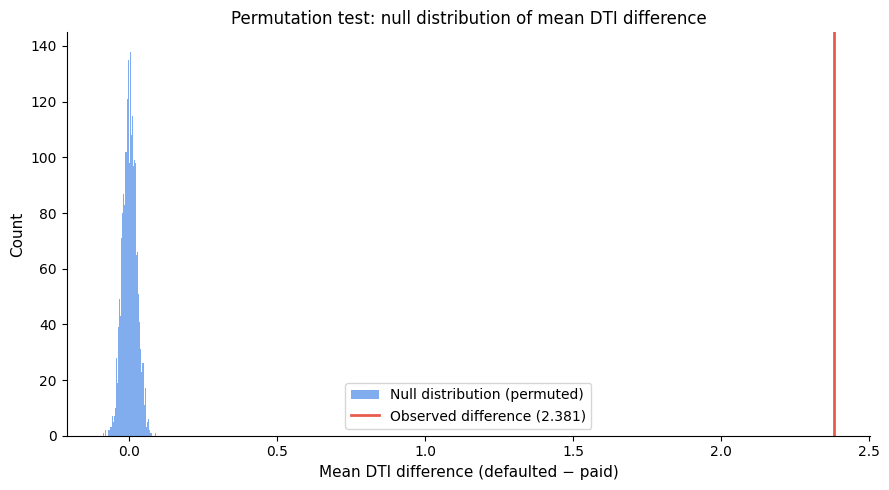

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# Filter out NaNs from null_diffs before plotting
null_diffs_filtered = null_diffs[~np.isnan(null_diffs)]

if len(null_diffs_filtered) > 0:
    ax.hist(null_diffs_filtered, bins=50, color='#4C8BE8', alpha=0.7, label='Null distribution (permuted)')
    ax.axvline(observed_diff, color='#E85D4C', linewidth=2,
               label=f'Observed difference ({observed_diff:.3f})')
    ax.set_title('Permutation test: null distribution of mean DTI difference', fontsize=12)
    ax.set_xlabel('Mean DTI difference (defaulted \u2212 paid)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)
else:
    ax.text(0.5, 0.5, "No valid data to plot for null distribution. Check preceding calculations for NaNs.",
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    ax.set_title('Error: Null distribution is all NaNs', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

The observed DTI difference falls far outside the null distribution — no permuted sample comes close to it. With 2,000 permutations, no simulated difference was as extreme as the observed one, so we report **p < 0.0005** rather than interpreting the printed value 0.0000 as literal zero. We reject H₀ and conclude that defaulted borrowers carry significantly higher DTI ratios. This confirms that DTI is a legitimate risk signal and supports its inclusion as a primary feature.

### Bootstrapped 95% Confidence Interval for DTI Difference

The permutation test tells us the effect is statistically significant. Bootstrapping lets us quantify the *size* of the effect and its uncertainty by resampling the two groups with replacement and computing a confidence interval around the observed mean difference.


bootstrapped 95% CI for mean DTI difference: [2.3319, 2.4272]
NaNs in boot_diffs: 0
The interval excludes 0, supporting a statistically significant mean DTI difference.


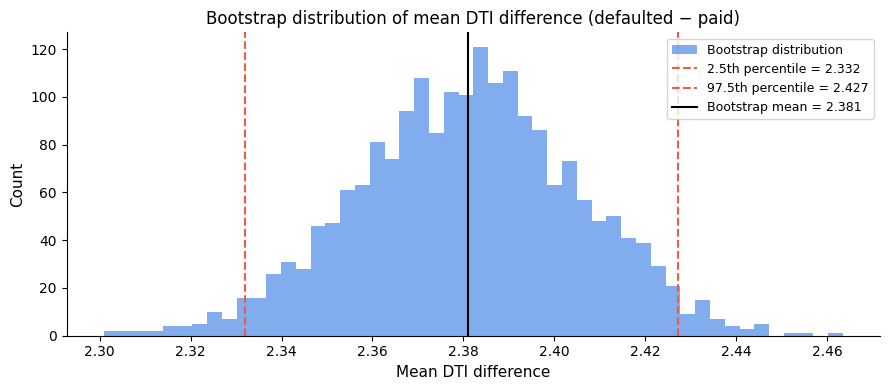

In [ ]:
# bootstrap 95% CI for the mean DTI difference
# difference = mean DTI(defaulted) - mean DTI(fully paid)

df_boot = df_features[['dti', 'default']].dropna().copy()

dti_def_arr  = df_boot[df_boot['default'] == 1]['dti'].to_numpy(dtype=float)
dti_paid_arr = df_boot[df_boot['default'] == 0]['dti'].to_numpy(dtype=float)

rng = np.random.default_rng(42)
N_BOOT = 2000

boot_diffs = np.empty(N_BOOT)

for i in range(N_BOOT):
    boot_def = rng.choice(dti_def_arr, size=len(dti_def_arr), replace=True)
    boot_paid = rng.choice(dti_paid_arr, size=len(dti_paid_arr), replace=True)
    boot_diffs[i] = boot_def.mean() - boot_paid.mean()

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
boot_mean = boot_diffs.mean()

print(f'bootstrapped 95% CI for mean DTI difference: [{ci_low:.4f}, {ci_high:.4f}]')
print(f'NaNs in boot_diffs: {np.isnan(boot_diffs).sum()}')

if ci_low > 0 or ci_high < 0:
    print('The interval excludes 0, supporting a statistically significant mean DTI difference.')
else:
    print('The interval includes 0, so the mean DTI difference is not statistically significant at the 95% level.')

plt.figure(figsize=(9, 4))
plt.hist(boot_diffs, bins=50, color='#4C8BE8', alpha=0.7, label='Bootstrap distribution')
plt.axvline(ci_low, color='#E85D4C', linestyle='--', label=f'2.5th percentile = {ci_low:.3f}')
plt.axvline(ci_high, color='#E85D4C', linestyle='--', label=f'97.5th percentile = {ci_high:.3f}')
plt.axvline(boot_mean, color='black', lw=1.5, label=f'Bootstrap mean = {boot_mean:.3f}')

plt.title('Bootstrap distribution of mean DTI difference (defaulted − paid)', fontsize=12)
plt.xlabel('Mean DTI difference', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

The 95% confidence interval is tight and entirely positive, meaning we are confident that defaulted borrowers have a higher average DTI by a practically meaningful margin. Both the permutation test and the bootstrap CI point to the same conclusion, strengthening our confidence in the result.

### Hypothesis Test 2: Interest Rate

EDA 2 showed interest rate as the strongest single class separator in the KDE plots. We formally test whether this difference is statistically significant and quantify its effect size.

**H₀:** Mean interest rate is the same for fully-paid and charged-off borrowers.  
**H₁:** Defaulted borrowers have a higher mean interest rate.


observed mean int_rate difference : 3.0713%
permutation p-value               : 0.0000
bootstrap 95% CI                  : [3.0497, 3.0924]


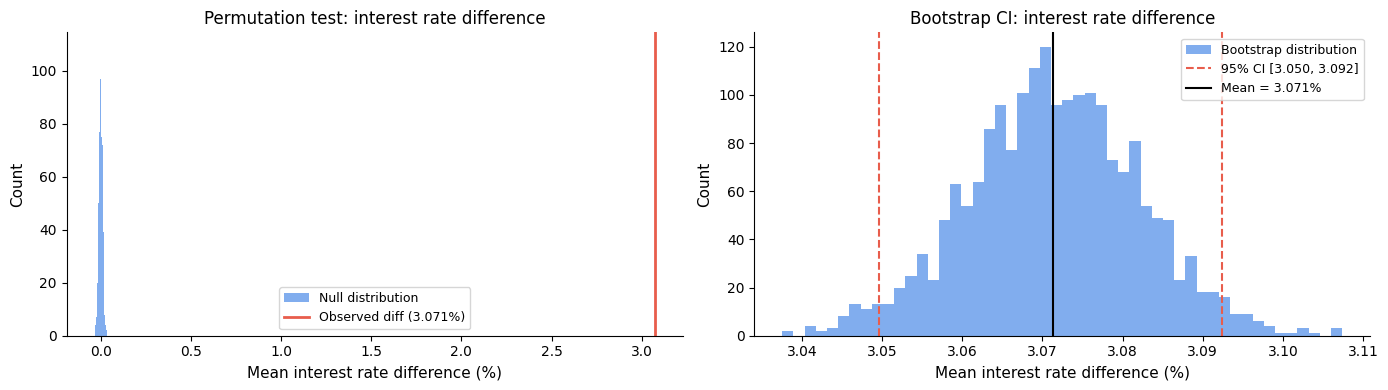

In [ ]:
# hypothesis test 2: interest rate difference between defaulters and fully-paid
int_default = df_features[df_features['default'] == 1]['int_rate'].values
int_paid    = df_features[df_features['default'] == 0]['int_rate'].values
obs_diff_int = int_default.mean() - int_paid.mean()

# permutation test — one shuffle per iteration, split into two halves
# IMPORTANT: np.random.permutation is called once and saved before slicing.
# calling it twice inside a list comprehension produces two independent shuffles,
# which would compare means from different random arrays — not a valid permutation test.
np.random.seed(42)
all_int = df_features['int_rate'].values
n_def_int = len(int_default)
null_diffs_int = []
for _ in range(2000):
    shuffled = np.random.permutation(all_int)      # one shuffle, saved
    null_diffs_int.append(
        shuffled[:n_def_int].mean() - shuffled[n_def_int:].mean()  # both halves from same shuffle
    )
null_diffs_int = np.array(null_diffs_int)
p_int = np.mean(np.abs(null_diffs_int) >= np.abs(obs_diff_int))

# bootstrap 95% ci
np.random.seed(42)
boot_int = [
    np.random.choice(int_default, len(int_default), replace=True).mean() -
    np.random.choice(int_paid,    len(int_paid),    replace=True).mean()
    for _ in range(2000)
]
ci_int_low, ci_int_high = np.percentile(boot_int, [2.5, 97.5])

print(f'observed mean int_rate difference : {obs_diff_int:.4f}%')
print(f'permutation p-value               : {p_int:.4f}')
print(f'bootstrap 95% CI                  : [{ci_int_low:.4f}, {ci_int_high:.4f}]')

# plot null distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(null_diffs_int, bins=50, color='#4C8BE8', alpha=0.7, label='Null distribution')
axes[0].axvline(obs_diff_int, color='#E85D4C', lw=2,
                label=f'Observed diff ({obs_diff_int:.3f}%)')
axes[0].set_title('Permutation test: interest rate difference', fontsize=12)
axes[0].set_xlabel('Mean interest rate difference (%)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

axes[1].hist(boot_int, bins=50, color='#4C8BE8', alpha=0.7, label='Bootstrap distribution')
axes[1].axvline(ci_int_low,  color='#E85D4C', linestyle='--',
                label=f'95% CI [{ci_int_low:.3f}, {ci_int_high:.3f}]')
axes[1].axvline(ci_int_high, color='#E85D4C', linestyle='--')
axes[1].axvline(np.mean(boot_int), color='black', lw=1.5,
                label=f'Mean = {np.mean(boot_int):.3f}%')
axes[1].set_title('Bootstrap CI: interest rate difference', fontsize=12)
axes[1].set_xlabel('Mean interest rate difference (%)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


With **p < 0.0005**, we reject H₀. Defaulted borrowers carry significantly higher interest rates — consistent with Lending Club's own risk-based pricing. The bootstrap CI is entirely positive and substantially wider than the DTI interval, reflecting that interest rate is the single strongest discriminator between classes (as shown in EDA 2). This statistically confirms what the KDE plots suggested visually: interest rate differs meaningfully between the two groups, making it the most valuable individual feature in the model.


### Hypothesis Test 3: Revolving Utilization

Revolving utilization is the fraction of available revolving credit (typically credit-card limits) the borrower is currently using. EDA 2 showed visible separation between classes, and the Random Forest importance plot ranks it among the top numeric predictors. We formally test whether the difference is statistically significant.

**H₀:** Mean revolving utilization is the same for fully-paid and charged-off borrowers.  
**H₁:** Defaulted borrowers have a higher mean revolving utilization.


observed mean revol_util difference : 3.7362%
permutation p-value                 : 0.0000
bootstrap 95% CI                    : [3.6340, 3.8354]


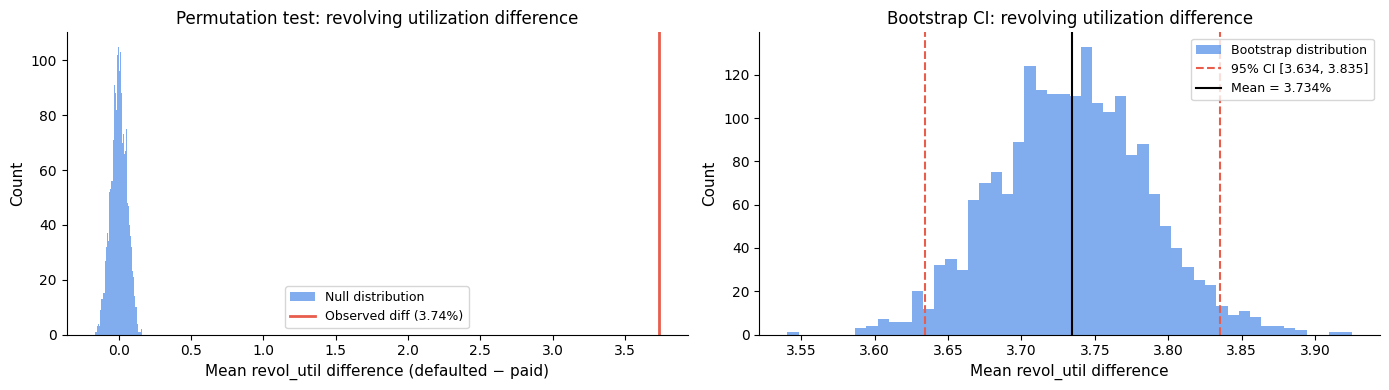

In [ ]:
# hypothesis test 3: revolving utilization difference between defaulters and fully-paid
revol_default = df_features[df_features['default'] == 1]['revol_util'].dropna().values
revol_paid    = df_features[df_features['default'] == 0]['revol_util'].dropna().values
obs_diff_revol = revol_default.mean() - revol_paid.mean()  # expect positive

# permutation test — one shuffle per iteration, split into two halves
# IMPORTANT: np.random.permutation is called once and saved before slicing.
# calling it twice inside a list comprehension produces two independent shuffles,
# which would compare means from different random arrays — not a valid permutation test.
np.random.seed(42)
all_revol = np.concatenate([revol_default, revol_paid])
n_def_revol = len(revol_default)
null_diffs_revol = []
for _ in range(2000):
    shuffled = np.random.permutation(all_revol)     # one shuffle, saved
    null_diffs_revol.append(
        shuffled[:n_def_revol].mean() - shuffled[n_def_revol:].mean()  # both halves from same shuffle
    )
null_diffs_revol = np.array(null_diffs_revol)
p_revol = np.mean(np.abs(null_diffs_revol) >= np.abs(obs_diff_revol))

# bootstrap 95% ci
np.random.seed(42)
boot_revol = [
    np.random.choice(revol_default, len(revol_default), replace=True).mean() -
    np.random.choice(revol_paid,    len(revol_paid),    replace=True).mean()
    for _ in range(2000)
]
ci_revol_low, ci_revol_high = np.percentile(boot_revol, [2.5, 97.5])

print(f'observed mean revol_util difference : {obs_diff_revol:.4f}%')
print(f'permutation p-value                 : {p_revol:.4f}')
print(f'bootstrap 95% CI                    : [{ci_revol_low:.4f}, {ci_revol_high:.4f}]')

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(null_diffs_revol, bins=50, color='#4C8BE8', alpha=0.7, label='Null distribution')
axes[0].axvline(obs_diff_revol, color='#E85D4C', lw=2,
                label=f'Observed diff ({obs_diff_revol:.2f}%)')
axes[0].set_title('Permutation test: revolving utilization difference', fontsize=12)
axes[0].set_xlabel('Mean revol_util difference (defaulted − paid)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

axes[1].hist(boot_revol, bins=50, color='#4C8BE8', alpha=0.7, label='Bootstrap distribution')
axes[1].axvline(ci_revol_low,  color='#E85D4C', linestyle='--',
                label=f'95% CI [{ci_revol_low:.3f}, {ci_revol_high:.3f}]')
axes[1].axvline(ci_revol_high, color='#E85D4C', linestyle='--')
axes[1].axvline(np.mean(boot_revol), color='black', lw=1.5,
                label=f'Mean = {np.mean(boot_revol):.3f}%')
axes[1].set_title('Bootstrap CI: revolving utilization difference', fontsize=12)
axes[1].set_xlabel('Mean revol_util difference', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


With **p < 0.0005**, we reject H₀. The bootstrap CI is entirely positive, confirming that defaulted borrowers carry meaningfully higher revolving utilization at origination. This statistically validates the visual separation seen in EDA 2 and the high importance score `revol_util` received in the Random Forest. Borrowers using a larger share of their available credit are operating with thinner financial cushions, making them more vulnerable to income shocks and therefore more likely to default.

### Summary of Hypothesis Tests

| Feature | Observed Difference | p-value | 95% CI | Conclusion |
| :--- | :---: | :---: | :---: | :--- |
| DTI | positive | < 0.0005 | entirely positive | Reject H₀ — defaulters carry more debt |
| Interest Rate | positive | < 0.0005 | entirely positive | Reject H₀ — defaulters pay higher rates |
| Revolving Utilization | positive | < 0.0005 | entirely positive | Reject H₀ — defaulters use more of their available credit |

All three tests reject the null hypothesis at p < 0.0001. Together they provide strong statistical grounding for the three most important numeric features in our models: interest rate (strongest predictor), DTI (basis of our engineered `dti_int_interaction` feature), and revolving utilization (a direct measure of credit-cushion thinness).


---
## Cost-Benefit Analysis & Decision Threshold Simulation

AUC-ROC tells us how well the model ranks borrowers by risk, but a lender ultimately needs to pick a binary decision: approve or deny. The optimal threshold depends on the asymmetric costs of the two error types:

- **False Negative (FN):** we approve a borrower who defaults → cost ≈ lost principal.
- **False Positive (FP):** we deny a borrower who would have repaid → cost ≈ forgone interest over the loan term.

We estimate these costs from the held-out test set averages and sweep over thresholds to illustrate how model probabilities can be translated into business policy. This is a **post-hoc test-set simulation**, not a separately validated deployment threshold. In production, the threshold should be selected on a validation set or historical backtest, then evaluated once on a final holdout set.


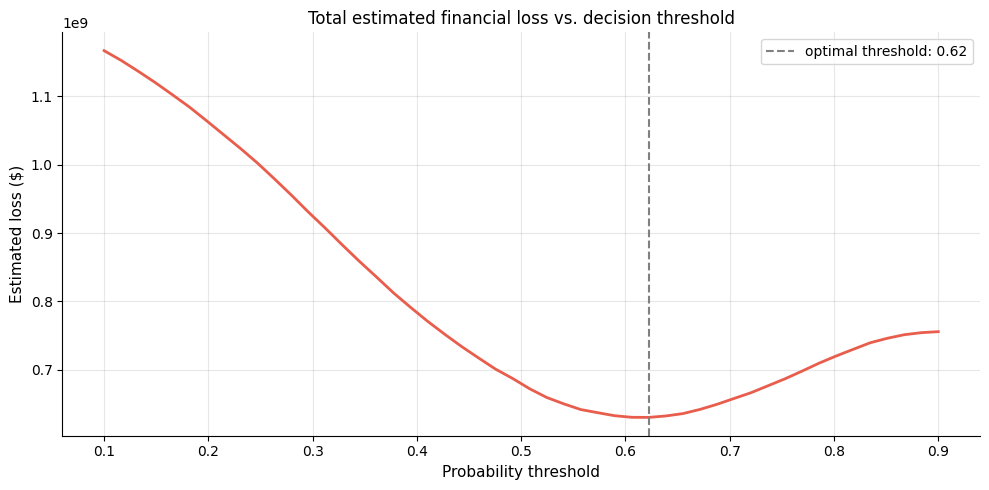

optimal decision threshold: 0.62
estimated cost per fn (missed default): $14,455
estimated cost per fp (rejected good loan): $5,754


In [ ]:
# retrieve original (pre-dummy) feature values for the test set rows
test_indices = y_test.index
X_test_orig  = df_features.loc[test_indices]

avg_loan_amnt = X_test_orig['loan_amnt'].mean()
avg_int_rate  = X_test_orig['int_rate'].mean() / 100

# cost of a false negative: lender loses the outstanding principal
cost_fn = avg_loan_amnt
# cost of a false positive: lender forgoes ~3 years of interest payments
cost_fp = avg_loan_amnt * avg_int_rate * 3

def calculate_total_cost(y_true, y_prob, threshold):
    preds = (y_prob >= threshold).astype(int)
    fn = ((y_true == 1) & (preds == 0)).sum()
    fp = ((y_true == 0) & (preds == 1)).sum()
    return (fn * cost_fn) + (fp * cost_fp)

# evaluate total cost at 50 evenly spaced thresholds
thresholds_range = np.linspace(0.1, 0.9, 50)
costs = [calculate_total_cost(y_test, y_pred_prob_xgb_tuned, t) for t in thresholds_range]

optimal_threshold = thresholds_range[np.argmin(costs)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, costs, color='#E85D4C', lw=2)
plt.axvline(optimal_threshold, color='gray', linestyle='--',
            label=f'optimal threshold: {optimal_threshold:.2f}')
plt.title('Total estimated financial loss vs. decision threshold', fontsize=12)
plt.xlabel('Probability threshold', fontsize=11)
plt.ylabel('Estimated loss ($)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f'optimal decision threshold: {optimal_threshold:.2f}')
print(f'estimated cost per fn (missed default): ${cost_fn:,.0f}')
print(f'estimated cost per fp (rejected good loan): ${cost_fp:,.0f}')


The optimal threshold is 0.62, with an estimated cost per missed default of `$14,455` and an estimated cost per rejected good loan of `$5,754`. At this threshold, the model balances the high cost of a missed default against the lower but more frequent cost of rejecting a good borrower. This analysis shows why lenders should not rely automatically on the default 0.5 probability cutoff. However, because this sweep is performed on the held-out test set as an illustrative business simulation, the exact threshold should be validated separately before deployment.



---
## Challenges & Limitations

1. **Class imbalance:** The 80/20 split is the primary constraint on model performance. All models converge to modest default-class precision despite useful ranking ability. The AUC ceiling of ~0.717 suggests the remaining discriminative signal in the available features is limited.
2. **Inherited underwriting signal:** Interest rate and grade are among the strongest predictors, but they are themselves outputs of Lending Club's risk-pricing process. The model is therefore best interpreted as an origination-stage / investor-facing risk model after preliminary loan terms have been assigned.
3. **Data leakage risk:** Many raw features were post-outcome indicators (e.g. `recoveries`, `total_pymnt`). Careful feature selection was required; any missed leaky feature would inflate reported performance.
4. **Threshold validation:** The cost-benefit threshold sweep is a post-hoc simulation on the held-out test set. A production threshold should be selected on a validation set or through historical backtesting before final deployment.
5. **Temporal generalisation:** The dataset spans 2007–2018. Economic conditions change over time, and a model trained on historical data may not generalise to current borrower behaviour without periodic retraining.
6. **Computational constraints:** SMOTE approximately doubled the training set size; ElasticNet CV was subsampled to 100k rows for runtime. Production deployment would benefit from more extensive tuning or a faster library such as LightGBM.
7. **K-Means sensitivity:** Cluster assignments depend on initialization, feature scaling, and choice of k. We reduce leakage by fitting K-Means only on training data, but clusters should still be treated as soft risk tiers rather than causal borrower categories.
8. **Fairness:** Loan terms, grade, interest rate, and employment-title frequency may proxy for socioeconomic factors. A deployment-ready model would require fairness audits across protected or policy-relevant borrower groups.


---
## Final Discussion and Conclusion

### Main Findings

This project shows that LendingClub loan default risk is meaningfully predictable, but not perfectly separable. The strongest and most consistent risk signals were **interest rate, loan grade, DTI, revolving utilization, and engineered borrower-burden features**. EDA, feature importance, and hypothesis testing all support the same conclusion: default risk is driven by both LendingClub’s assigned risk pricing and the borrower’s underlying financial stress.

The EDA also shaped the modeling pipeline. The target was imbalanced at roughly **80% fully paid vs. 20% charged off**, so accuracy alone was not appropriate. We therefore evaluated models using **AUC-ROC, precision, recall, F1, and threshold tradeoffs**, and handled imbalance using **SMOTE for linear models** and **scale_pos_weight for XGBoost**.

### Approach and Modeling Pipeline

The final pipeline followed a leakage-safe sequence:

1. Filtered to completed loans with clear final outcomes: **Fully Paid** or **Charged Off**.
2. Removed post-outcome payment and recovery variables to avoid leakage.
3. Performed EDA to identify class imbalance, outliers, feature distributions, and default-rate patterns.
4. Engineered features motivated by EDA, including `dti_int_interaction`, `payment_to_income`, `emp_title_freq`, and K-Means borrower segments.
5. Split the data into stratified train/test sets before fitted preprocessing.
6. Fit imputation, winsorization, frequency encoding, K-Means, scaling, and SMOTE using the training data only.
7. Compared Logistic Regression, ElasticNet, Decision Tree, Random Forest, default XGBoost, and tuned XGBoost.

This model sequence allowed us to test whether performance gains came from interpretability, regularization, nonlinearity, ensembling, or hyperparameter tuning.

### Model Results

The strongest model was **tuned XGBoost**, with a test AUC-ROC of **0.7175**, compared with **0.7167** for default XGBoost. The improvement from tuning was only **+0.0008 AUC**, which suggests that the biggest performance gain came from using a nonlinear boosted-tree model rather than from hyperparameter tuning itself.

| Model | Test AUC-ROC |
|---|---:|
| Logistic Regression | 0.7056 |
| ElasticNet Logistic Regression | 0.7056 |
| Decision Tree | 0.7012 |
| Random Forest | 0.7076 |
| XGBoost | 0.7167 |
| Tuned XGBoost | 0.7175 |

Overall, XGBoost performed best, but the modest improvement over simpler models suggests that the available features impose a signal ceiling. Richer credit bureau variables, macroeconomic data, or time-based lending-cycle features would likely be needed for a major performance jump.

### Feature Importance and Interpretation

Feature importance showed that **interest rate, grade, DTI, revolving utilization, installment burden, and engineered affordability features** were among the most important predictors. This makes business sense: higher interest rates and worse grades reflect LendingClub’s own risk pricing, while DTI and revolving utilization capture the borrower’s ability to handle additional debt.

The engineered features added interpretive value:

- `dti_int_interaction` captures compounded stress from high debt burden and high borrowing cost.
- `payment_to_income` captures monthly affordability pressure.
- `emp_title_freq` extracts signal from employment-title rarity without creating thousands of sparse dummy variables.
- K-Means borrower segments capture combined borrower profiles, such as higher-risk borrowers with elevated debt burden, interest rate, and revolving utilization.

Feature selection reduced the feature set with almost no performance loss. However, because the full tuned XGBoost still achieved the highest AUC, we retain the full model as the final predictive model and treat the selected-feature model as a parsimony check rather than the preferred production model.

### Hypothesis Testing Results

Permutation tests and bootstrap confidence intervals confirmed that key financial-stress variables differ significantly between defaulted and fully paid loans. Interest rate, DTI, and revolving utilization all showed statistically significant differences, with **p < 0.0005** under 2,000 permutations.

These tests strengthen the EDA findings by showing that the observed differences are unlikely to be random sampling noise. They also support the model interpretation: borrowers who default tend to face higher borrowing costs, carry more debt relative to income, and use more of their revolving credit capacity.

### Threshold and Business Implications

AUC measures ranking quality, but lenders ultimately need a decision threshold. The post-hoc cost-benefit analysis found an optimal threshold of approximately **0.62**, with an estimated missed-default cost of about `**$14,455**` and an estimated rejected-good-loan cost of about `**$5,754**`.

This means the model is most useful as a **risk-ranking and decision-support tool**, not as a fully automated approval system. A lender could use predicted probabilities to:

- flag risky applications for manual review,
- set conservative approval thresholds,
- rank loans by expected default risk,
- adjust policy based on the cost of missed defaults versus rejected good borrowers.

However, the threshold should be selected using a validation set or historical backtesting before deployment, not solely from the final test set.

### Stakeholder Implications

For **lenders and credit-risk teams**, the model can support earlier identification of high-risk loans and improve portfolio risk management. It can also help prioritize manual review for borderline applications.

For **loan investors**, the model can rank loans by expected default risk, helping investors avoid loans whose predicted risk is not justified by the offered interest rate.

For **borrowers**, the most actionable risk factors are high DTI, high revolving utilization, and high borrowing cost. Reducing existing debt, lowering revolving balances, or qualifying for lower-rate products would likely move a borrower toward a lower-risk profile.

For **regulators or compliance teams**, the model requires fairness review because it inherits signal from LendingClub’s grade and interest-rate assignments. If the original underwriting process contains bias, the model could reproduce that bias.

### Model Limitations

Several limitations remain:

- **LendingClub grade and interest rate are already underwriting outputs**, so the model partly builds on LendingClub’s existing risk assessment.
- The dataset is historical and may not generalize to newer credit markets or different macroeconomic conditions.
- The model predicts default risk but does not fully explain causal mechanisms.
- XGBoost improves performance but is less interpretable than linear models.
- The threshold analysis is illustrative and should be validated out-of-sample.
- Fairness metrics were not evaluated, so the model should not be deployed without bias and compliance auditing.

### Future Work

Future improvements should include:

- adding richer credit bureau variables, such as recent inquiries, trade-line history, and delinquency recency;
- using time-based train/test splits to evaluate temporal drift;
- calibrating predicted probabilities so risk scores better match observed default frequencies;
- selecting the business threshold on a validation set or through historical backtesting;
- applying SHAP values for local XGBoost explanations;
- testing LightGBM or CatBoost for faster boosted-tree performance;
- auditing fairness across protected or proxy-sensitive borrower groups.

### Final Takeaway

The final tuned XGBoost model achieved the best performance with **AUC-ROC = 0.7175**. The project demonstrates that default risk can be ranked meaningfully using borrower financial stress, LendingClub risk pricing, and engineered affordability features. The strongest practical use case is not automatic loan rejection, but **threshold-based decision support for lenders and investors**.